# Advanced Techniques for Language Models

**Mini-Assignment 1**

---

António Cruz (140129), Bruno Santos (140586), Pedro Miranda (129268)

# 1. Business Understanding

## 1.1 The scale of the problem

Hiring is among the most resource-intensive processes in any organization, and a
significant share of that cost traces directly to the recruitment pipeline
itself, job advertising, recruiter time, applicant screening, and interview
coordination, rather than the employee's eventual compensation. In the United
States, the SHRM 2025 Talent Acquisition Benchmarking Report places the average
recruitment cost per hire at \$5,475 for non-executive roles and \$35,879 for
executive positions, representing a 21% increase from 2022 [shrm2025]. In the
United Kingdom, the Chartered Institute of Personnel and Development (CIPD)
estimates the average recruitment cost per hire at £6,125, encompassing internal
staff time and external fees such as job advertising and agency charges
[cipd2025]. The scale of the recruitment market is substantial: the EURES portal
alone publishes approximately 60 million job vacancies per year across Europe
[eures2024], while LinkedIn hosts roughly 15.7 million active job listings
globally [novoresume2026]. Each unfilled vacancy costs organizations an estimated
\$500 per day in lost productivity [shrm2025], and the average time to fill a
position ranges from 36 to 42 days [recruitee2025]. At this volume, even small
inefficiencies in the hiring funnel compound into substantial financial waste.

## 1.2 Where the problem is most acute

Recruitment cost and difficulty vary dramatically by sector. Technology companies
spent \$6,000-\$8,000 per hire in 2023, while healthcare organizations faced
recruitment costs of \$9,000-\$12,000 due to credentialing, regulatory
compliance, and acute talent shortages [engagedly2025]. Technical roles such as
engineering positions can reach \$10,000-\$20,000 per hire [timeclick2026]. In
Europe, the EURES 2024 Report on Labour Shortages and Surpluses confirms that
severe shortages persist in highly skilled professions as healthcare,
engineering, and IT, as well as in trades such as welding, electrical work, and
construction [eures2024]. All 31 EURES countries reported shortage occupations
across nearly all occupational categories, with Malta, Slovakia, Bulgaria, Italy,
and Romania identifying the greatest numbers [eures2024]. These are precisely the
sectors where job descriptions demand the most precision, niche skill
combinations, regulatory language, and accurate seniority calibration, and where
vague or generic postings fail most visibly.

## 1.3 The regulatory landscape

The job description challenge is compounded by an evolving regulatory environment
on both sides of the Atlantic. In the United States, multiple states, including
California, Colorado, New York, and Massachusetts, have enacted pay transparency
laws requiring salary ranges in job postings [vbeyond2025]. In Europe, the
regulatory pressure is even more significant. The EU Pay Transparency Directive
(Directive (EU) 2023/970), which must be transposed into national law by 7 June
2026, requires all employers across all 27 member states to include salary ranges
or starting pay levels in job postings, use gender-neutral job titles and
descriptions, and refrain from asking candidates about their salary history
[ogletree2026]. Vague formulations such as "competitive salary" or "negotiable"
will no longer satisfy legal requirements [salarytransparency2026]. Some member
states, including Ireland and the Netherlands, are adopting stricter
interpretations that mandate salary ranges directly in the advertisement itself
[salarytransparency2026]. This regulatory shift transforms job description
quality from a best practice into a compliance obligation, making structured,
template-aware generation tools not merely convenient but operationally necessary
for organizations hiring across European markets.

## 1.4 What makes a good job description

Research consistently demonstrates that job description quality directly
determines hiring outcomes and defines the criteria our system must enforce.
According to Indeed, 52% of job seekers report that the quality of a job
description is "very" or "extremely" influential in their decision to apply, and
63% of candidates have declined to apply because they did not understand the
required skills or tools [indeed2024]. On the supply side, up to 42% of received
resumes do not meet basic job requirements [sullivan2020], a problem driven by
vague or inflated postings. Organizations that publish "roles with unclear
requirements and inflated expectations" directly contribute to talent shortages
[isolved2026]. Inclusive language has measurable impact: job descriptions written
with gender-neutral language receive up to 42% more responses [compono2025], and
61% of candidates identify the salary range as the single most important element
in a job posting [linkedin2025]. According to Glassdoor, 70% of applicants want
salary information before taking any further step in the application process
[glassdoor2023]. These findings define the quality criteria that generated job
descriptions must enforce: structural completeness (job title, role summary,
responsibilities, required skills, qualifications, and benefits), salary
transparency with realistic ranges, specific and calibrated skill requirements,
inclusive and gender-neutral language, and consistent seniority alignment
throughout the posting.

## 1.5 Project objective and three-stage plan

The objective of the project is a language model that can produce a complete, well-structured job posting from a short brief: a role title, a few required skills, a seniority level and any organisational constraints. Instead of using a large general-purpose model directly, the project builds a smaller specialised model in three stages. Each stage adds one capability, moving from domain knowledge, to instruction-following, to a complete supported system.

Two public datasets support all three stages. The first is the Djinni Recruitment Dataset [djinni2024], available on HuggingFace, with about 142,000 English-language job descriptions from the Djinni IT job platform (2020 to 2023). It includes structured fields such as position title, full description, company name, experience requirement, primary keyword and English proficiency level. The second is the LinkedIn Job Postings dataset [kagglelinkedin], available on Kaggle, a cross-industry collection of postings with structured metadata such as title, company, description, location and work type. The Data Understanding phase (Section 2) examines both datasets in detail before any training decision is taken.

### 1.5.1 Mini-Assignment 1: domain adaptation

The goal of the first stage, which is the subject of this report, is to teach a pretrained language model what job postings sound like: their vocabulary, their section structure and their domain-specific phrasing. This is done by continued pretraining on raw job-description text. The next-token prediction objective is unchanged; only the training data is domain-specific. By the end of the stage the model should assign clearly lower perplexity to held-out job postings than the base model does.

The base model is SmolLM2-360M, small enough to train on a single GPU. The continued-pretraining corpus is built from the Djinni dataset: a fixed sample of cleaned job descriptions, split into disjoint training, validation and in-domain test sets. LinkedIn is kept aside as an out-of-domain test set and is never trained on. Training uses the HuggingFace Transformers Trainer, and the experiment compares the two optimisation methods described in Section 1.6, full fine-tuning and LoRA. The model is evaluated by perplexity on the held-out splits and by qualitative inspection of prompted text completions.

### 1.5.2 Mini-Assignment 2: alignment

The domain-adapted model from Mini-Assignment 1 can produce text that looks like a job posting, but it cannot yet follow a specific instruction such as a request for a posting for a senior Python developer, remote, in fintech. The second stage adds two training phases. Supervised fine-tuning on instruction-and-response pairs teaches the model to generate a job description on demand. Preference alignment with Direct Preference Optimization then teaches it to prefer responses that respect the stated constraints, use inclusive language, stay structurally complete and keep the seniority level consistent.

Both phases use the HuggingFace TRL library. The supervised fine-tuning dataset is built from existing postings by pairing each posting with a plausible instruction that could have produced it. The preference dataset is built by sampling several candidate outputs from the model and ranking them with a stronger model acting as judge. Evaluation is a three-way comparison between the base model, the domain-adapted model and the aligned model, on a fixed prompt set, using both automatic metrics and a review of how well each output satisfies its constraints.

### 1.5.3 Final Project: system integration

The final stage wraps the aligned model into a working system that closes two remaining gaps: grounding the output in real market data, and checking output quality automatically.

Two components are added on top of the model. The first is Retrieval-Augmented Generation: a search index is built over the original job postings, and when a user requests a posting, similar real postings are retrieved and supplied as context, so the output reflects real market conventions. The second is an evaluation loop in which a separate model scores each draft against a quality rubric covering section completeness, skill coverage, seniority consistency and inclusive language; if the score is too low, the critique is fed back and the posting is regenerated. The system is reachable through a simple entry point, and is evaluated against the Mini-Assignment 2 model and the base model on a fixed set of test prompts.


## 1.6 Key concepts and methodology

This section explains, in plain terms, the technical ideas the rest of the notebook relies on. It is meant to make the report readable without prior background in language modelling.

A language model is a program that, given a piece of text, predicts the next word. By repeating that prediction it can also generate new text. Modern language models are first trained on very large amounts of general text in a step called pretraining. Pretraining is expensive and produces a general-purpose model that already knows grammar, common facts and a broad vocabulary, but is not specialised in any particular domain.

The base model is the starting point of this project: a model that has already been pretrained by its authors and is published ready to use. This project uses SmolLM2-360M, an openly available model with about 360 million parameters. It was chosen because it is small enough to train on a single consumer GPU, while still being large enough to produce readable job-posting text.

Continued pretraining means taking that base model and training it further on text from a specific domain, here job postings. The training objective does not change: the model still only learns to predict the next word. What changes is the data. After continued pretraining the model has seen many job postings and has adjusted its internal weights toward the wording, structure and vocabulary typical of recruitment text. This process is also called domain adaptation. It does not teach the model to follow instructions; it only makes it fluent in the domain.

Before any text reaches the model it is split into tokens. A token is a small unit of text, often a whole common word but sometimes only a word fragment. The model reads and predicts tokens, not characters. Tokenisation matters in practice because a rare technical term may be split into several tokens, which makes it harder for the model to learn and uses up more of the fixed input budget. Section 2.7 measures this directly.

The experiment in this report compares two ways of carrying out the continued pretraining.

Full fine-tuning updates every weight in the model. It is the most direct method and usually the most effective, but it is also the most demanding: it needs enough memory to hold and update all 360 million parameters, and it produces a complete new copy of the model.

LoRA, short for Low-Rank Adaptation, takes a different approach. It freezes the original weights and inserts a small number of new, trainable parameters next to them. Only those new parameters are trained. LoRA therefore updates a tiny fraction of the model, uses less memory, and produces a small adapter file instead of a full model copy. The question the experiment answers is whether this cheaper method can match full fine-tuning on this task.

The model is judged mainly by perplexity. Perplexity measures how surprised a language model is by a piece of text it did not train on. It is computed from the model's average prediction error, and a lower value means the model found the text more predictable. A model well adapted to job postings should assign low perplexity to unseen job postings.

Perplexity is measured on two separate test sets. The in-domain test set contains Djinni IT postings that the model never saw during training. The out-of-domain test set contains LinkedIn postings from many industries. Comparing the two answers an important question: does adapting the model to IT job postings also help it on job postings from other fields, or is the benefit specific to IT? This in-domain versus out-of-domain contrast is used throughout the Evaluation phase.

The work in this report follows the CRISP-DM methodology, a standard process model for data projects. Its phases map directly onto the sections that follow: Business Understanding in this phase, then Data Understanding, Data Preparation, Modeling, Evaluation and Deployment.


# 2. Data Understanding

The Data Understanding phase examines both datasets before any modelling decision is taken. Its purpose is to learn what the data contains, how clean it is, and which of its properties should shape the training corpus built in Section 3.

## 2.1 Environment and data loading

This section imports the libraries used throughout the notebook and loads the two datasets. Every later analysis reuses the dataframes created here.


In [2]:
# Imports and shared paths used throughout the notebook.
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Show more text per cell so long job descriptions stay readable in tables.
pd.set_option("display.max_colwidth", 120)

# Locate the project root (the folder that contains data/).
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
JOBS = PROJECT_ROOT / "data" / "jobs"

print("Project root :", PROJECT_ROOT)
print("Jobs data dir:", JOBS)
assert JOBS.exists(), f"data/jobs not found starting from {Path.cwd()}"

Project root : /home/pedro/iscte/atlm_pro
Jobs data dir: /home/pedro/iscte/atlm_pro/data/jobs


The two datasets are loaded below. The cell prints a row-and-column summary for each, so their relative size is clear before the analysis begins.


In [3]:
# Load Djinni (the core IT dataset); drop the leftover pandas index column.
djinni = pd.read_parquet(JOBS / "djinni" / "train-00000-of-00001.parquet")
djinni = djinni.drop(columns=["__index_level_0__"], errors="ignore")

# Load LinkedIn (cross-industry); read only the columns this analysis needs.
linkedin_keep = ["job_id", "title", "description", "company_name", "location",
                 "formatted_work_type", "formatted_experience_level", "skills_desc"]
linkedin = pd.read_csv(JOBS / "linkedin" / "postings.csv", usecols=linkedin_keep)

# Collect both dataframes and show a row-and-column summary of each.
datasets = {"Djinni": djinni, "LinkedIn": linkedin}

pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Rows":    [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
})


,Dataset,Rows,Columns
0,Djinni,141897,9
1,LinkedIn,123849,8


Djinni contains 141,897 IT job postings and LinkedIn contains 123,849 postings from many industries. Both are large enough for every split this project needs. Djinni is the larger and more uniform dataset and is used for training; LinkedIn is reserved for out-of-domain testing.

## 2.2 Djinni: the core dataset

The Djinni dataset (`lang-uk/recruitment-dataset-job-descriptions-english` on HuggingFace) contains real IT job postings scraped from the Djinni platform between 2020 and 2023. It is the core dataset of this project and the only one used for training.

This section examines the dataset from six angles: its schema and missing values, the spread of technical domains, the quality and length of the description text, the structured fields that could serve as prompt inputs, the relationship between description length and seniority, and whether the descriptions are genuine or templated.


### 2.2.1 Schema and missing values

The first step is to confirm which columns the dataset provides and how complete each one is. A field with heavy missingness cannot be relied on as a prompt input.


In [3]:
# Per-column schema: data type, non-null count, percent missing, distinct values.
print(f"Shape: {djinni.shape[0]:,} rows by {djinni.shape[1]} columns\n")

schema = pd.DataFrame({
    "dtype":      [djinni[c].dtype for c in djinni.columns],
    "non_null":   [djinni[c].notna().sum() for c in djinni.columns],
    "missing_%":  [(djinni[c].isna().mean() * 100).round(2) for c in djinni.columns],
    "n_unique":   [djinni[c].nunique() for c in djinni.columns],
}, index=djinni.columns)

display(schema)


Shape: 141,897 rows by 9 columns



,dtype,non_null,missing_%,n_unique
Position,str,141897,0.00,69671
Long Description,str,141897,0.00,141897
Company Name,str,141897,0.00,10894
Exp Years,str,141897,0.00,5
Primary Keyword,str,141897,0.00,45
English Level,str,134358,5.31,5
Published,str,141897,0.00,45
Long Description_lang,str,141897,0.00,1
id,str,141897,0.00,141897


The dataset has 141,897 rows and 9 columns. Seven columns are fully populated; English Level is the only field with a notable gap, missing for 5.31 percent of rows. Position, Long Description and id are unique per row, while Exp Years and Primary Keyword take only a few distinct values, which makes them well suited as structured prompt fields.

### 2.2.2 Primary keyword (tech domain) distribution

The Primary Keyword field labels the technology or role domain of each posting. It is the strongest single structured signal in the dataset, so its distribution determines which domains the model sees most often.


45 distinct primary keywords



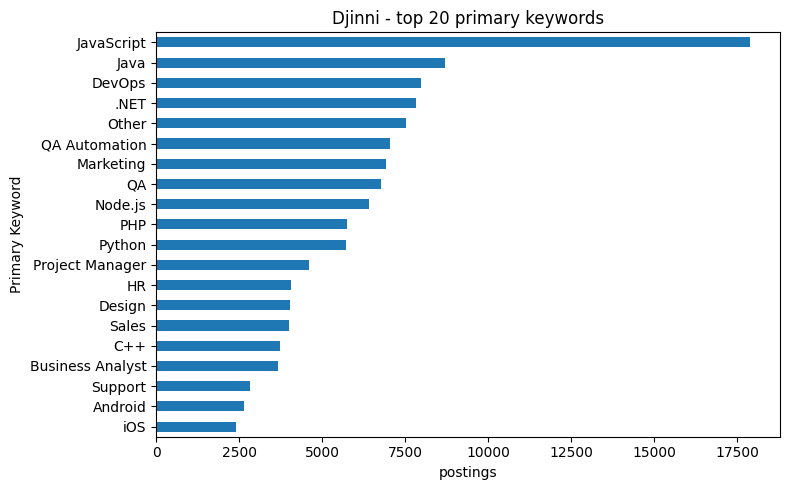

,keyword,postings
0,JavaScript,17903
1,Java,8712
2,DevOps,7979
3,.NET,7826
4,Other,7536
5,QA Automation,7047
6,Marketing,6933
7,QA,6774
8,Node.js,6416
9,PHP,5740


In [4]:
# Count postings per primary keyword and plot the 20 most frequent.
kw = djinni["Primary Keyword"].value_counts()
print(f"{kw.size} distinct primary keywords\n")

ax = kw.head(20).iloc[::-1].plot.barh(
    figsize=(8, 5), title="Djinni - top 20 primary keywords")
ax.set_xlabel("postings")
plt.tight_layout()
plt.show()

# Full list for reference
display(kw.reset_index().rename(columns={"Primary Keyword": "keyword", "count": "postings"}))


The postings spread across 45 primary keywords, but the distribution is heavily skewed. JavaScript alone accounts for 17,903 postings, followed by Java, DevOps and .NET. A long tail of keywords has very few postings, four of them only one. The dataset is strongly weighted toward mainstream web and back-end technologies. This is acceptable for continued pretraining, where the aim is broad exposure to job-posting language rather than balanced coverage of every niche.

### 2.2.3 Target text quality (Long Description)

The Long Description field is the text the model will be trained on, so its quality is critical. This subsection checks how many descriptions are present and unique, and how their length is distributed.


Non-null descriptions : 141,897  (100.0%)
Unique descriptions   : 141,897  (100.0%)
Duplicate ratio       : 0.000

Length in characters:
count    141897.0
mean       1801.0
std         973.0
min          51.0
25%        1109.0
50%        1629.0
75%        2284.0
max       12578.0
Name: Long Description, dtype: float64


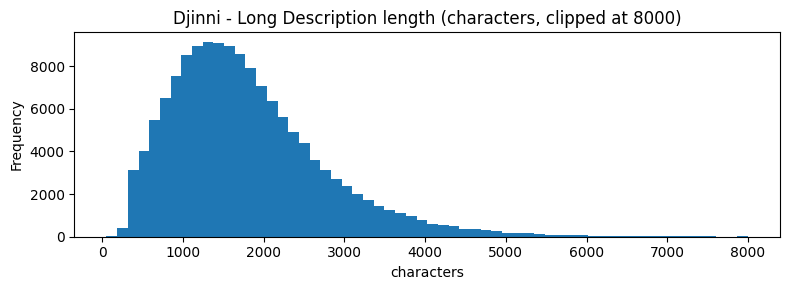

In [5]:
# Measure how many descriptions are present and unique, summarise their
# character length, and plot the length distribution.
text = djinni["Long Description"].dropna().astype(str)

print(f"Non-null descriptions : {len(text):,}  ({len(text)/len(djinni):.1%})")
print(f"Unique descriptions   : {text.nunique():,}  ({text.nunique()/len(text):.1%})")
print(f"Duplicate ratio       : {1 - text.nunique()/len(text):.3f}\n")
print("Length in characters:")
print(text.str.len().describe().round(0))

ax = text.str.len().clip(upper=8000).plot.hist(
    bins=60, figsize=(8, 3),
    title="Djinni - Long Description length (characters, clipped at 8000)")
ax.set_xlabel("characters")
plt.tight_layout()
plt.show()


All 141,897 descriptions are present and unique: there are no missing or duplicated descriptions, which is unusually clean. Length is right-skewed, with a median of 1,629 characters and a mean of 1,801, but the shortest description is only 51 characters and the longest reaches 12,578. The skew and the very short outliers are what justify the length bounds applied when the corpus is built in Section 3.

### 2.2.4 Structured prompt features: experience level and English level

Exp Years and English Level are the two categorical fields that could be combined with Primary Keyword to form richer prompts in later assignments. This subsection measures their coverage and distributions, and whether they carry overlapping or complementary information.


,Feature,Non-null,Non-null %,N distinct,Values
0,Exp Years,141897,100.00,5,"2y, 5y, 1y, 3y, no_exp"
1,English Level,134358,94.69,5,"intermediate, fluent, upper, pre, basic"


Exp Years_clean
3y        49996
2y        36150
5y        27772
1y        22007
no_exp     5972
Name: count, dtype: int64

English Level_clean
upper           66948
intermediate    54965
fluent          10583
NaN              7539
pre              1689
basic             173
Name: count, dtype: int64

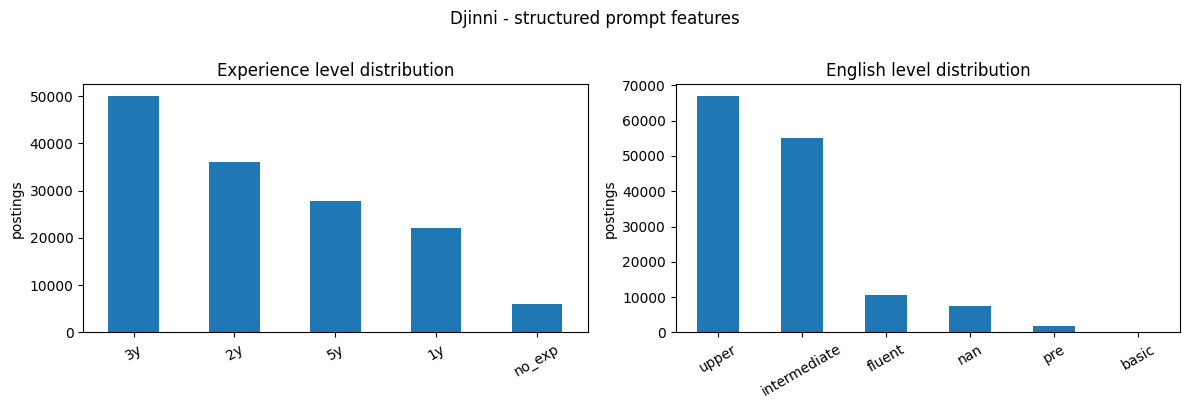

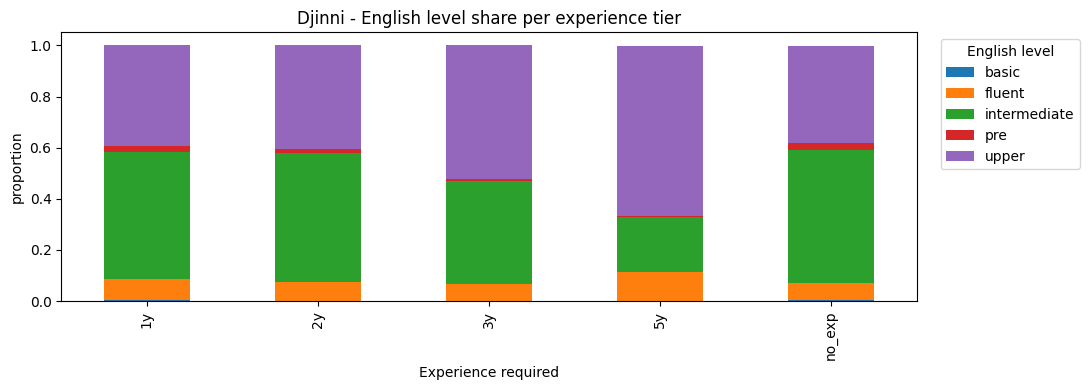

English Level_clean,basic,fluent,intermediate,pre,upper
Exp Years_clean,,,,,
1y,0.003,0.084,0.496,0.024,0.394
2y,0.001,0.072,0.506,0.017,0.404
3y,0.001,0.064,0.403,0.008,0.524
5y,0.001,0.112,0.214,0.004,0.668
no_exp,0.003,0.069,0.519,0.026,0.382


In [6]:
# Coverage and distributions of the two categorical prompt fields, and a
# cross-tab showing how experience level and English level relate.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Clean values
djinni["Exp Years_clean"] = djinni["Exp Years"].astype(str).str.strip()
djinni["English Level_clean"] = djinni["English Level"].astype(str).str.strip()

# Remove fake nan strings
djinni.loc[djinni["Exp Years"].isna(), "Exp Years_clean"] = pd.NA
djinni.loc[djinni["English Level"].isna(), "English Level_clean"] = pd.NA

# Coverage
cov = pd.DataFrame({
    "Feature": ["Exp Years", "English Level"],
    "Non-null": [
        djinni["Exp Years"].notna().sum(),
        djinni["English Level"].notna().sum()
    ],
    "Non-null %": [
        round(djinni["Exp Years"].notna().mean() * 100, 2),
        round(djinni["English Level"].notna().mean() * 100, 2)
    ],
    "N distinct": [
        djinni["Exp Years_clean"].nunique(dropna=True),
        djinni["English Level_clean"].nunique(dropna=True)
    ],
    "Values": [
        ", ".join(djinni["Exp Years_clean"].dropna().unique().astype(str)),
        ", ".join(djinni["English Level_clean"].dropna().unique().astype(str))
    ]
})

display(cov)

# Real distributions
exp_counts = djinni["Exp Years_clean"].value_counts(dropna=False)
eng_counts = djinni["English Level_clean"].value_counts(dropna=False)

display(exp_counts)
display(eng_counts)

# Side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not exp_counts.empty:
    exp_counts.plot.bar(ax=axes[0], rot=30)
    axes[0].set_title("Experience level distribution")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("postings")
else:
    axes[0].text(0.5, 0.5, "No Exp Years data", ha="center", va="center")
    axes[0].set_axis_off()

if not eng_counts.empty:
    eng_counts.plot.bar(ax=axes[1], rot=30)
    axes[1].set_title("English level distribution")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("postings")
else:
    axes[1].text(0.5, 0.5, "No English Level data", ha="center", va="center")
    axes[1].set_axis_off()

plt.suptitle("Djinni - structured prompt features", y=1.01)
plt.tight_layout()
plt.show()

# Cross-tab
ct = pd.crosstab(
    djinni["Exp Years_clean"],
    djinni["English Level_clean"],
    normalize="index"
).round(3)

if ct.empty:
    print("Cross-tab is empty. There is no overlap between Exp Years and English Level.")
else:
    ax = ct.plot.bar(
        figsize=(11, 4),
        stacked=True,
        title="Djinni - English level share per experience tier"
    )
    ax.set_xlabel("Experience required")
    ax.set_ylabel("proportion")
    ax.legend(title="English level", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    display(ct)

Exp Years is present for every row and takes five ordered values, with mid-level experience most common (3 years, 49,996 postings). English Level covers 94.7 percent of rows and is dominated by the upper and intermediate levels. The cross-tabulation shows the two fields are related but not redundant: the share of upper English rises steadily with required experience, from 39 percent at one year to 67 percent at five years. Both fields are usable as prompt inputs, and together they carry more signal than either alone.

### 2.2.5 Description length vs seniority

This subsection checks whether more senior roles come with longer descriptions. If they do, experience level is a useful cue for how long a generated posting should be.


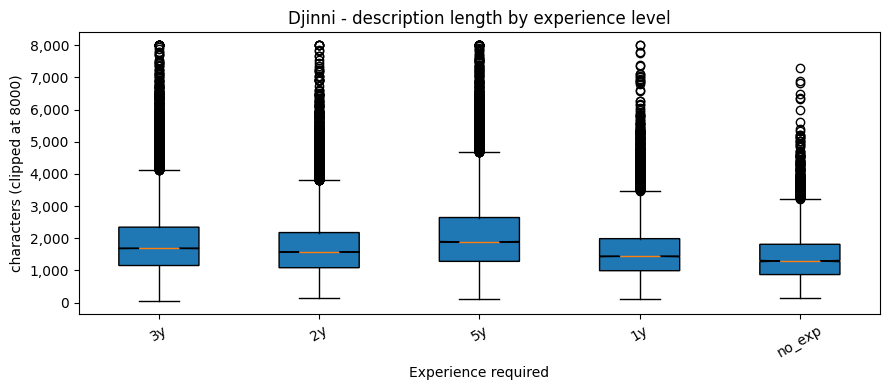

,n,mean,median
Exp Years_clean,,,
3y,49996,1845.0,1685.0
2y,36150,1721.0,1574.0
5y,27772,2076.0,1887.0
1y,22007,1579.0,1437.0
no_exp,5972,1445.0,1292.0


In [7]:
# Compare description length across experience levels with a boxplot.
djinni["desc_len"] = djinni["Long Description"].astype(str).str.len()
djinni["Exp Years_clean"] = djinni["Exp Years"].astype(str).str.strip()

# Use the experience-level values that actually occur in the dataset.
present_exp = djinni["Exp Years_clean"].dropna().value_counts().index.tolist()

box_data = []

for e in present_exp:
    values = (
        djinni.loc[djinni["Exp Years_clean"] == e, "desc_len"]
        .clip(upper=8000)
        .dropna()
        .to_numpy()
    )
    
    if len(values) > 0:
        box_data.append(values)

if len(box_data) == 0:
    print("No valid data available for boxplot.")
    display(djinni["Exp Years"].value_counts(dropna=False))
else:
    fig, ax = plt.subplots(figsize=(9, 4))

    ax.boxplot(
        box_data,
        tick_labels=present_exp,
        notch=True,
        patch_artist=True
    )

    ax.set_title("Djinni - description length by experience level")
    ax.set_xlabel("Experience required")
    ax.set_ylabel("characters (clipped at 8000)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    exp_stats = (
        djinni[djinni["Exp Years_clean"].isin(present_exp)]
        .groupby("Exp Years_clean")["desc_len"]
        .agg(n="count", mean="mean", median="median")
        .round(0)
        .reindex(present_exp)
    )

    display(exp_stats)

Description length rises steadily with required experience. Roles with no experience requirement average 1,445 characters, climbing through each tier to 2,076 characters for five-year roles. More senior positions are described in more detail, so experience level is a useful cue for how long a generated posting should be.

### 2.2.6 Repetition and template detection

A dataset built from a few repeated templates would teach the model very little. This subsection counts how many distinct descriptions exist per keyword. If each keyword mapped to only one description, the dataset would be a lookup table rather than a genuine language resource.


In [8]:
# Count distinct descriptions per keyword, to check for templated text.
diversity = (
    djinni.groupby("Primary Keyword")["Long Description"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="distinct_descriptions")
)

print("Distinct descriptions per keyword - summary:")
display(diversity.describe().round(0))
print("\nTop 15 keywords by description variety:")
display(diversity.head(15))


Distinct descriptions per keyword - summary:


,distinct_descriptions
count,45.0
mean,3153.0
std,3472.0
min,1.0
25%,554.0
50%,1861.0
75%,4618.0
max,17903.0



Top 15 keywords by description variety:


,Primary Keyword,distinct_descriptions
0,JavaScript,17903
1,Java,8712
2,DevOps,7979
3,.NET,7826
4,Other,7536
5,QA Automation,7047
6,Marketing,6933
7,QA,6774
8,Node.js,6416
9,PHP,5740


There is no template problem. Because every description is unique, the count of distinct descriptions per keyword simply equals the number of postings for that keyword, from a single posting for the rarest keywords up to 17,903 for JavaScript. Every posting contributes genuinely different text, which is exactly what continued pretraining needs.

## 2.3 LinkedIn: the out-of-domain test set

The LinkedIn Job Postings dataset (from Kaggle) is a real, cross-industry collection of job postings. It is held out entirely from training and used only as an out-of-domain test set, to measure how well a model trained on IT postings generalises to other industries.

This section examines the dataset along the same lines as Djinni: schema and missing values, description quality and length, the spread of job families, the coverage of structured metadata, and repetition.


### 2.3.1 Schema and missing values

The same completeness check applied to Djinni, now for LinkedIn.


In [9]:
# Per-column schema for LinkedIn: type, non-null count, percent missing, distinct values.
print(f"Shape: {linkedin.shape[0]:,} rows by {linkedin.shape[1]} columns\n")

schema_li = pd.DataFrame({
    "dtype":     [linkedin[c].dtype for c in linkedin.columns],
    "non_null":  [linkedin[c].notna().sum() for c in linkedin.columns],
    "missing_%": [(linkedin[c].isna().mean() * 100).round(2) for c in linkedin.columns],
    "n_unique":  [linkedin[c].nunique() for c in linkedin.columns],
}, index=linkedin.columns)

display(schema_li)


Shape: 123,849 rows by 8 columns



,dtype,non_null,missing_%,n_unique
job_id,int64,123849,0.00,123849
company_name,str,122130,1.39,24428
title,str,123849,0.00,72521
description,str,123842,0.01,107827
location,str,123849,0.00,8526
formatted_work_type,str,123849,0.00,7
formatted_experience_level,str,94440,23.75,6
skills_desc,str,2439,98.03,2212


LinkedIn has 123,849 rows and 8 columns. The core fields are essentially complete, but two have heavy missingness: experience level is absent for 23.8 percent of rows, and skills_desc is absent for 98 percent, leaving only 2,439 usable values. skills_desc is therefore not a dependable field. Unlike Djinni, the description field also contains some duplicates, examined next.

### 2.3.2 Target text quality (description)

This subsection checks how many LinkedIn descriptions are present and unique, and how their length compares with Djinni's.


Non-null descriptions : 123,842  (100.0%)
Unique descriptions   : 107,827  (87.1%)
Duplicate ratio       : 0.129

Length in characters:
count    123842.0
mean       3766.0
std        2146.0
min           2.0
25%        2176.0
50%        3435.0
75%        4986.0
max       23201.0
Name: description, dtype: float64


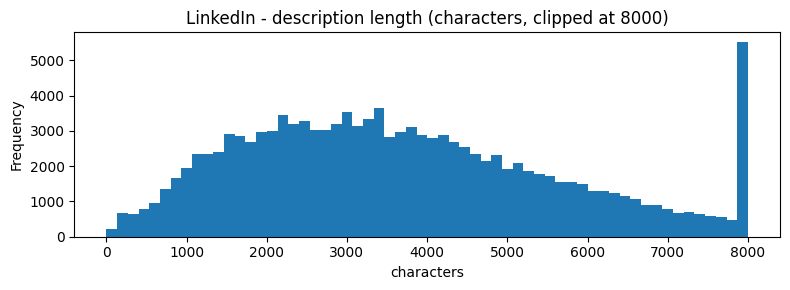

In [10]:
# Measure how many LinkedIn descriptions are present and unique, and
# plot their character-length distribution.
li_text = linkedin["description"].dropna().astype(str)

print(f"Non-null descriptions : {len(li_text):,}  ({len(li_text)/len(linkedin):.1%})")
print(f"Unique descriptions   : {li_text.nunique():,}  ({li_text.nunique()/len(li_text):.1%})")
print(f"Duplicate ratio       : {1 - li_text.nunique()/len(li_text):.3f}\n")
print("Length in characters:")
print(li_text.str.len().describe().round(0))

ax = li_text.str.len().clip(upper=8000).plot.hist(
    bins=60, figsize=(8, 3),
    title="LinkedIn - description length (characters, clipped at 8000)")
ax.set_xlabel("characters")
plt.tight_layout()
plt.show()


Descriptions are present for almost every row, but only 87.1 percent are unique: about 13 percent are duplicates, most likely the same posting re-listed. The text is also much longer than Djinni's, with a median of 3,435 characters against 1,629. Both facts shape corpus construction: LinkedIn text must be deduplicated, and length bounds are needed to trim the long tail.

### 2.3.3 Job family distribution

LinkedIn spans many industries. A keyword-based taxonomy groups job titles into broad families, which shows how cross-industry the out-of-domain test set really is.


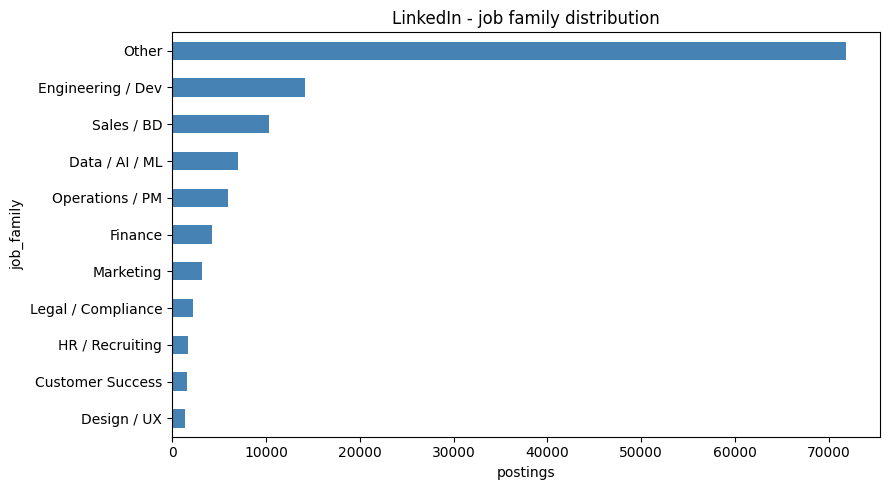

,family,postings
0,Other,71850
1,Engineering / Dev,14207
2,Sales / BD,10327
3,Data / AI / ML,7056
4,Operations / PM,6014
5,Finance,4219
6,Marketing,3153
7,Legal / Compliance,2258
8,HR / Recruiting,1700
9,Customer Success,1644


In [11]:
# Group LinkedIn job titles into broad families using keyword patterns,
# then count and plot the families.
import re

family_map = {
    "Engineering / Dev":  r"engineer|developer|software|backend|frontend|fullstack|devops|sre|cloud",
    "Data / AI / ML":     r"data |machine learning|analyst|scientist|analytics|\bbi\b|nlp|llm|\bai\b",
    "Design / UX":        r"design|ux |ui |product design|creative",
    "Marketing":          r"market|seo|growth|brand|content|social media|copywriter",
    "Sales / BD":         r"sales|account exec|business dev|account manager",
    "Finance":            r"finance|accountant|financi|controller|audit|\btax\b",
    "HR / Recruiting":    r"recruiter|talent|human resource|\bhr\b|people ops",
    "Operations / PM":    r"operat|product manager|project manager|scrum|agile|supply",
    "Customer Success":   r"customer success|support|\bcx\b|service desk|helpdesk",
    "Legal / Compliance": r"legal|counsel|compliance|attorney|paralegal",
}

def classify_title(title):
    t = str(title).lower()
    for family, pattern in family_map.items():
        if re.search(pattern, t):
            return family
    return "Other"

linkedin["job_family"] = linkedin["title"].map(classify_title)
family_counts = linkedin["job_family"].value_counts()

ax = family_counts.sort_values().plot.barh(
    figsize=(9, 5), color="steelblue",
    title="LinkedIn - job family distribution")
ax.set_xlabel("postings")
plt.tight_layout()
plt.show()

display(family_counts.reset_index().rename(columns={"job_family": "family", "count": "postings"}))


Grouping titles into broad families confirms that LinkedIn is genuinely cross-industry. The largest bucket is Other, with 71,850 postings, meaning most LinkedIn titles fall outside the IT-oriented families this taxonomy was built around. Among the recognised families, Engineering and Development is the largest at 14,207, but the IT families combined are only about a sixth of the dataset. This is the opposite of Djinni, and exactly the property wanted in an out-of-domain test set.

### 2.3.4 Structured metadata coverage

This subsection checks which LinkedIn fields are complete enough to act as prompt inputs or as filters during evaluation.


In [12]:
# Coverage and example values for the LinkedIn fields that could serve
# as prompt inputs or evaluation filters.
meta_cols = ["title", "formatted_work_type", "formatted_experience_level",
             "location", "company_name", "skills_desc"]

meta = pd.DataFrame({
    "Feature":    meta_cols,
    "Non-null %": [(linkedin[c].notna().mean() * 100).round(2) for c in meta_cols],
    "N distinct": [linkedin[c].nunique() for c in meta_cols],
    "Example values": [
        ", ".join(linkedin[c].dropna().astype(str).unique()[:4])
        for c in meta_cols
    ],
})
display(meta)


,Feature,Non-null %,N distinct,Example values
0,title,100.00,72521,"Marketing Coordinator, Mental Health Therapist/Counselor, Assitant Restaurant Manager, Senior Elder Law / Trusts and..."
1,formatted_work_type,100.00,7,"Full-time, Internship, Contract, Part-time"
2,formatted_experience_level,76.25,6,"Entry level, Mid-Senior level, Associate, Director"
3,location,100.00,8526,"Princeton, NJ, Fort Collins, CO, Cincinnati, OH, New Hyde Park, NY"
4,company_name,98.61,24428,"Corcoran Sawyer Smith, The National Exemplar , Abrams Fensterman, LLP, Downtown Raleigh Alliance"
5,skills_desc,1.97,2212,Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in P...


Title, work type and location are fully populated, with clean, low-cardinality categories. Experience level covers about three quarters of rows. skills_desc, at under 2 percent coverage, is unusable. The dependable LinkedIn fields for evaluation are therefore title, work type and location.

### 2.3.5 Repetition and template detection

The same repetition check applied to Djinni: how many distinct descriptions exist per job title.


In [13]:
# Count distinct descriptions per job title, to check for repeated postings.
li_div = (
    linkedin.dropna(subset=["title", "description"])
    .groupby("title")["description"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="distinct_descriptions")
)

print("Distinct descriptions per title - summary:")
display(li_div.describe().round(0))
print("\nTop 15 titles by description variety:")
display(li_div.head(15))


Distinct descriptions per title - summary:


,distinct_descriptions
count,72516.0
mean,2.0
std,5.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,345.0



Top 15 titles by description variety:


,title,distinct_descriptions
0,Project Manager,345
1,Customer Service Representative,270
2,Administrative Assistant,243
3,Senior Accountant,234
4,Salesperson,204
5,Registered Nurse,201
6,Staff Accountant,197
7,Account Executive,183
8,Executive Assistant,178
9,Controller,168


Most LinkedIn titles map to a single description, with a median of one. A few generic titles repeat heavily, the most extreme being Project Manager with 345 distinct descriptions. This is consistent with the 13 percent duplicate rate and reinforces the decision to deduplicate LinkedIn text before using it as a test set.

## 2.4 Comparative analysis

This section places Djinni and LinkedIn side by side on the dimensions that matter for training: the quantity and quality of the text, the richness of the vocabulary, and the most frequent terms in each.


### 2.4.1 Target text quality

A direct side-by-side comparison of the description text in the two datasets.


In [14]:
# Side-by-side text-quality metrics for the two datasets: counts,
# uniqueness, duplicate ratio and length statistics.
target_cols = {"Djinni": "Long Description", "LinkedIn": "description"}

rows_tq = []
for name, col in target_cols.items():
    t = datasets[name][col].dropna().astype(str)
    rows_tq.append({
        "Dataset":        name,
        "Target column":  col,
        "Non-null":       len(t),
        "Unique":         t.nunique(),
        "Duplicate ratio": round(1 - t.nunique() / len(t), 4),
        "Avg length":     round(t.str.len().mean(), 0),
        "Median length":  round(t.str.len().median(), 0),
        "Min length":     int(t.str.len().min()),
        "Max length":     int(t.str.len().max()),
    })

display(pd.DataFrame(rows_tq))


,Dataset,Target column,Non-null,Unique,Duplicate ratio,Avg length,Median length,Min length,Max length
0,Djinni,Long Description,141897,141897,0.0000,1801.0,1629.0,51,12578
1,LinkedIn,description,123842,107827,0.1293,3766.0,3435.0,2,23201


The side-by-side view confirms the earlier findings. Djinni has more postings, all unique, while LinkedIn carries a 13 percent duplicate rate. LinkedIn descriptions are roughly twice as long on average, 3,766 against 1,801 characters. Djinni is the cleaner and more uniform dataset, which supports using it for training and LinkedIn only for testing.

### 2.4.2 Lexical diversity

Lexical diversity is the ratio of unique words to total words in a text sample. A higher value means a more varied vocabulary, and indicates how rich the language the model is exposed to will be.


In [15]:
# Lexical diversity (unique words divided by total words) on a sample of each dataset.
import re

def lexical_diversity(series, sample_size=5000):
    text = " ".join(
        series.dropna().astype(str).head(sample_size).str.lower().tolist()
    )
    words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9+#.-]{2,}\b", text)
    if not words:
        return 0, 0, 0.0
    return len(words), len(set(words)), round(len(set(words)) / len(words), 4)

rows_ld = []
for name, col in target_cols.items():
    total, unique, ratio = lexical_diversity(datasets[name][col])
    rows_ld.append({
        "Dataset": name, "Column": col,
        "Total tokens (sample)": total,
        "Unique tokens": unique,
        "Lexical diversity": ratio,
    })

display(pd.DataFrame(rows_ld))


,Dataset,Column,Total tokens (sample),Unique tokens,Lexical diversity
0,Djinni,Long Description,1020803,22368,0.0219
1,LinkedIn,description,2059537,67524,0.0328


On a 5,000-document sample, LinkedIn shows higher lexical diversity (0.033) than Djinni (0.022). This is expected: LinkedIn spans many industries and uses a wider vocabulary, while Djinni's IT focus makes its language more repetitive. Djinni's narrower vocabulary is an advantage for training, since the model can specialise; LinkedIn's broader vocabulary makes it a genuinely harder out-of-domain target.

### 2.4.3 Most common terms

A qualitative view of the vocabulary each dataset uses most.


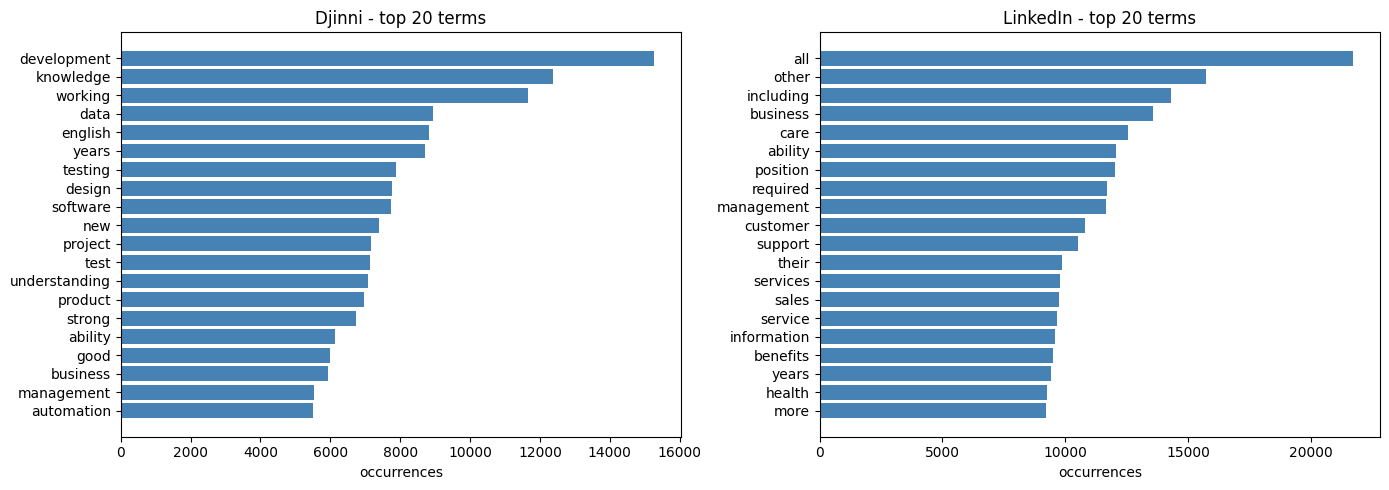

In [16]:
# Most frequent content words in each dataset, after removing common stop words.
from collections import Counter

STOPWORDS = {
    "the", "and", "for", "with", "you", "are", "our", "will", "this", "that",
    "from", "have", "your", "job", "work", "team", "experience", "skills",
    "candidate", "company", "role", "responsibilities", "requirements"
}

def top_terms(series, n=20):
    text = " ".join(series.dropna().astype(str).head(10_000).str.lower())
    words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9+#.-]{2,}\b", text)
    words = [w for w in words if w not in STOPWORDS]
    return pd.DataFrame(Counter(words).most_common(n), columns=["term", "count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, col) in zip(axes, target_cols.items()):
    terms = top_terms(datasets[name][col])
    ax.barh(terms["term"][::-1], terms["count"][::-1], color="steelblue")
    ax.set_title(f"{name} - top 20 terms")
    ax.set_xlabel("occurrences")
plt.tight_layout()
plt.show()


After common stop words are removed, the most frequent terms are clearly domain-specific. Djinni's top terms are dominated by software and engineering vocabulary, while LinkedIn's are broader and more business-oriented. This vocabulary gap is what the out-of-domain test is designed to expose: a model tuned on Djinni's terms is not automatically prepared for LinkedIn's.

## 2.5 Prompt-readiness assessment

This section estimates how much of each dataset could realistically be turned into prompt-and-completion pairs for the later assignments.

### 2.5.1 Prompt-readiness score

A row is counted as prompt-ready when its description is present and at least 200 characters long, and at least one structured field is also present. The count of such rows is the realistic ceiling on the number of usable prompt-and-completion pairs.


In [17]:
# Count prompt-ready rows: a description of at least MIN_LEN characters
# plus at least one structured field. Also reports why rows are dropped.
MIN_LEN = 200

rows_pr = []

# Djinni
has_desc = djinni["Long Description"].notna() & (djinni["Long Description"].str.len() >= MIN_LEN)
has_feat = djinni[["Primary Keyword", "Exp Years"]].notna().any(axis=1)
ready = has_desc & has_feat
rows_pr.append({
    "Dataset": "Djinni",
    "Total rows": len(djinni),
    "Prompt-ready rows": int(ready.sum()),
    "Ready %": round(ready.mean() * 100, 1),
    "Dropped (short or null description)": int((~has_desc).sum()),
    "Dropped (no structured feature)": int((has_desc & ~has_feat).sum()),
})

# LinkedIn
has_desc_li = linkedin["description"].notna() & (linkedin["description"].str.len() >= MIN_LEN)
has_feat_li = linkedin[["title", "formatted_experience_level"]].notna().any(axis=1)
ready_li = has_desc_li & has_feat_li
rows_pr.append({
    "Dataset": "LinkedIn",
    "Total rows": len(linkedin),
    "Prompt-ready rows": int(ready_li.sum()),
    "Ready %": round(ready_li.mean() * 100, 1),
    "Dropped (short or null description)": int((~has_desc_li).sum()),
    "Dropped (no structured feature)": int((has_desc_li & ~has_feat_li).sum()),
})

display(pd.DataFrame(rows_pr))


,Dataset,Total rows,Prompt-ready rows,Ready %,Dropped (short or null description),Dropped (no structured feature)
0,Djinni,141897,141859,100.0,38,0
1,LinkedIn,123849,123222,99.5,627,0


Almost all content in both datasets is prompt-ready: 100 percent of Djinni rows and 99.5 percent of LinkedIn rows. Only 38 Djinni descriptions and 627 LinkedIn descriptions are too short or missing, and no row fails for lack of a structured field. Data quantity is not a constraint for any stage of the project.

### 2.5.2 Recommendations

The findings above translate into the following decisions for corpus construction (Section 3) and evaluation (Section 5).

| Finding | Decision |
|---|---|
| Djinni is IT-only; LinkedIn spans many industries. | Train and validate on Djinni; use LinkedIn only as an out-of-domain test set. |
| Description length is right-skewed in both datasets, with a long tail of very long postings. | Apply character-length bounds when building the corpus, to drop stubs and outliers. |
| Exp Years and English Level together cover almost all Djinni rows and carry complementary signal (Section 2.2.4). | Keep both as candidate prompt fields for the later assignments. |
| skills_desc is missing for 98 percent of LinkedIn rows (Section 2.3.1). | Do not rely on skills_desc as a required field. |
| Description length rises with seniority in Djinni (Section 2.2.5). | Experience level is a useful prompt cue for output length. |
| About 13 percent of LinkedIn descriptions are duplicates (Section 2.3.5). | Deduplicate LinkedIn text before using it as a test set. |


## 2.6 Skill-to-role mapping

The project objective is to turn an informal brief into a structured job posting, which means the model must connect skills to roles. This section checks whether that connection actually exists in the data: do technical skills and domain terms appear consistently near specific job roles?

If they do, the dataset can teach the model genuine skill-to-role patterns rather than isolated templates. For example, if Figma and UX terms cluster around design roles, and Kubernetes and CI/CD around DevOps roles, the model has a real signal to learn from.


Rows with at least one extracted skill : 116,104  (81.8%)
Total skill mentions         : 404,876


,skill,mentions
0,SQL,42268
1,JavaScript,42175
2,Architecture,38469
3,Scrum/Agile,36949
4,AWS,26930
5,UX/UI,24460
6,React,23308
7,CI/CD,22547
8,Python,22414
9,Stakeholder Mgmt,22089


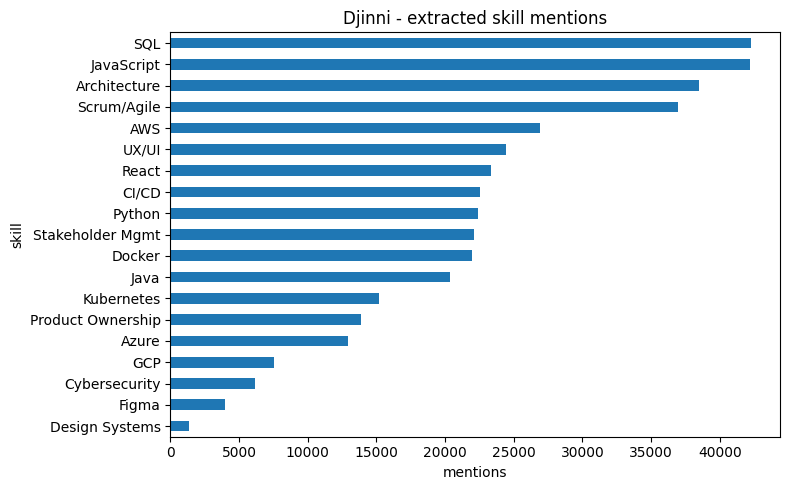

In [18]:
# Extract recognised skills from each Djinni description (keyword heuristic).
import re
from collections import Counter

# Skill detection is a transparent keyword heuristic: approximate, used to
# characterise the corpus, not as ground-truth labelling. Every short token is
# \b-bounded so it can't match inside another word (e.g. "soc" in "associate",
# "iam" in "claim"); ambiguous words ("pipeline", "container", "security") are
# tightened into discriminating phrases.
SKILL_PATTERNS = {
    "Figma":                r"\bfigma\b",
    "UX/UI":                r"\bux\b|\bui\b|user experience|user interface",
    "Design Systems":       r"design system",
    "SQL":                  r"\bsql\b|postgres|mysql|sql server|oracle",
    "Azure":                r"\bazure\b",
    "AWS":                  r"\baws\b|amazon web services",
    "GCP":                  r"\bgcp\b|google cloud",
    "Kubernetes":           r"kubernetes|\bk8s\b",
    "Docker":               r"\bdocker\b|containeri[sz]",
    "CI/CD":                r"ci/cd|\bcicd\b|continuous integration|continuous delivery|continuous deployment|deployment pipeline|build pipeline",
    "Python":               r"\bpython\b",
    "Java":                 r"\bjava\b",
    "JavaScript":           r"javascript|\bjs\b|typescript",
    "React":                r"\breact\b|reactjs",
    "Scrum/Agile":          r"\bscrum\b|\bagile\b|kanban",
    "Product Ownership":    r"product owner|backlog|roadmap|user stories",
    "Cybersecurity":        r"cyber|\bsiem\b|\biam\b|\bsoc\b|vulnerabilit|infosec|information security|network security|application security|cloud security|penetration test",
    "Architecture":         r"architect|solution design",
    "Stakeholder Mgmt":     r"stakeholder|business team|cross-functional|multi[- ]team",
}

def extract_skills(text):
    t = str(text).lower()
    return [skill for skill, pat in SKILL_PATTERNS.items()
            if re.search(pat, t, flags=re.IGNORECASE)]

# Build skill_df: one row per (description, skill) pair, via explode.
base = djinni.dropna(subset=["Long Description", "Primary Keyword"]).copy()
base["extracted_skills"] = base["Long Description"].apply(extract_skills)

# explode turns the list column into one row per (description, skill).
skill_df = (
    base[["Primary Keyword", "extracted_skills"]]
    .explode("extracted_skills")
    .dropna(subset=["extracted_skills"])
    .rename(columns={"Primary Keyword": "role_or_domain", "extracted_skills": "skill"})
    .reset_index(drop=True)
)

n_with_skill = (base["extracted_skills"].str.len() > 0).sum()
print(f"Rows with at least one extracted skill : {n_with_skill:,}  ({n_with_skill/len(base):.1%})")
print(f"Total skill mentions         : {len(skill_df):,}")

if skill_df.empty:
    print("No skills extracted - check SKILL_PATTERNS against the actual vocabulary.")
else:
    top_skill_counts = skill_df["skill"].value_counts().reset_index()
    top_skill_counts.columns = ["skill", "mentions"]
    display(top_skill_counts)

    ax = top_skill_counts.head(20).iloc[::-1].plot.barh(
        x="skill", y="mentions", legend=False, figsize=(8, 5),
        title="Djinni - extracted skill mentions")
    ax.set_xlabel("mentions")
    plt.tight_layout()
    plt.show()

The keyword heuristic finds at least one recognised skill in 81.8 percent of Djinni postings, for a total of 404,876 skill mentions. The most frequent skills are SQL, JavaScript, Architecture and Scrum/Agile. This coverage is high enough to support the next step, which checks whether these skills line up with specific roles.

### 2.6.1 Most associated role/domain per skill

This subsection shows, for each skill, the job domains it most often co-occurs with. It answers a core project question: when a brief mentions a skill, which role does the data associate with it?


,skill,role_or_domain,count
9,AWS,DevOps,5206
13,AWS,Java,3198
18,AWS,Node.js,2982
54,Architecture,JavaScript,5162
53,Architecture,Java,4263
40,Architecture,.NET,3515
81,Azure,.NET,2936
90,Azure,DevOps,2625
95,Azure,JavaScript,919
129,CI/CD,DevOps,5302


role_or_domain,.NET,Business Analyst,Data Science,Design,DevOps,Java,JavaScript,Lead,Node.js,Other,PHP,Project Manager,Python,QA,QA Automation
skill,,,,,,,,,,,,,,,
AWS,1464,139,663,20,5206,3198,2691,598,2982,511,1185,132,2464,355,1167
Architecture,3515,767,622,419,2802,4263,5162,1320,2753,1171,1613,517,2168,1271,1464
CI/CD,1561,70,210,13,5302,2216,2578,386,1379,391,767,196,1178,595,2412
Docker,1437,46,273,9,4641,3107,2058,337,1822,275,1687,43,2014,321,1239
Java,306,135,318,27,1234,8148,1249,407,348,453,174,110,356,584,2805
JavaScript,2962,149,139,357,983,2447,15892,579,5932,1144,3261,172,1500,937,2442
Python,305,204,1637,29,3941,913,992,386,494,586,312,87,5403,574,2028
React,1499,79,34,111,346,1310,11323,397,2724,598,1043,107,1015,282,461
SQL,4831,856,1255,30,2757,4990,2881,542,3272,1264,4000,164,3042,2662,2354


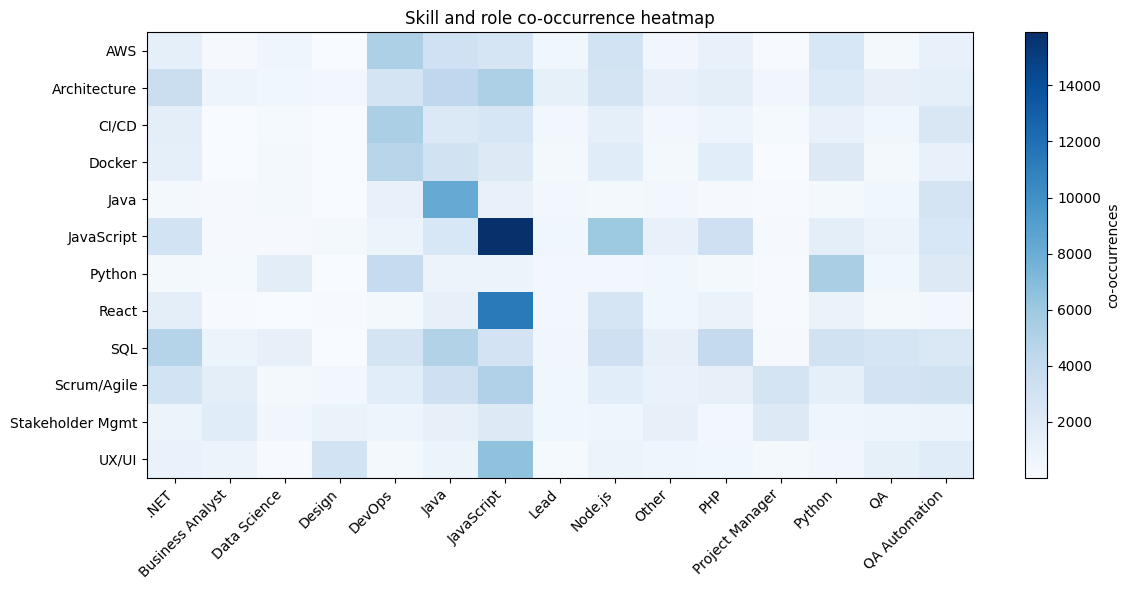

In [19]:
# For each skill, find its top-3 associated roles, then draw a
# skill-by-role co-occurrence heatmap.
if not skill_df.empty:
    # Top-3 roles per skill
    skill_role = (
        skill_df.groupby(["skill", "role_or_domain"])
        .size()
        .reset_index(name="count")
        .sort_values(["skill", "count"], ascending=[True, False])
    )
    most_associated = skill_role.groupby("skill").head(3)
    display(most_associated)

    # Heatmap: use size() instead of count() on a text column
    top_skills = skill_df["skill"].value_counts().head(12).index
    top_roles  = skill_df["role_or_domain"].value_counts().head(15).index

    pivot = (
        skill_df[
            skill_df["skill"].isin(top_skills) &
            skill_df["role_or_domain"].isin(top_roles)
        ]
        .groupby(["skill", "role_or_domain"])
        .size()
        .unstack(fill_value=0)
    )
    display(pivot)

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(pivot.values, aspect="auto", cmap="Blues")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Skill and role co-occurrence heatmap")
    fig.colorbar(im, ax=ax, label="co-occurrences")
    plt.tight_layout()
    plt.show()


The associations are coherent. Infrastructure skills concentrate around DevOps: CI/CD, Docker and Kubernetes all have DevOps as their leading role. Figma maps most strongly to Design, React and UX/UI to front-end JavaScript work, and Product Ownership to Business Analyst and Product Manager roles. Skills are not scattered randomly; they form recognisable role profiles. This confirms the dataset can teach skill-to-role patterns, which is the foundation the later assignments build on.

## 2.7 Tokenisation analysis

Character counts are a rough guide, but a language model is trained on tokens, not characters. This section measures token counts with the actual SmolLM2-360M tokenizer. The results inform the block size used for training and confirm whether long postings need to be trimmed.


/home/pedro/iscte/atlm_pro/.venv_atlm_pro/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded tokenizer: HuggingFaceTB/SmolLM2-360M



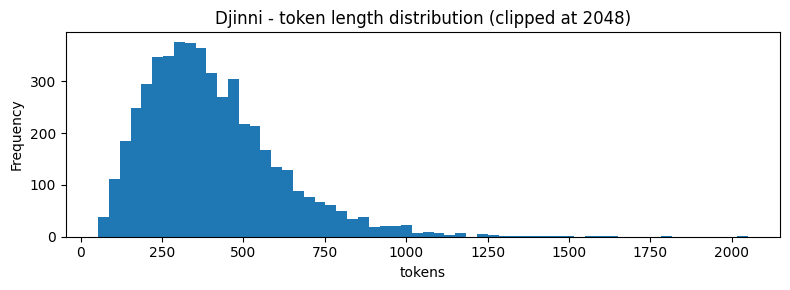

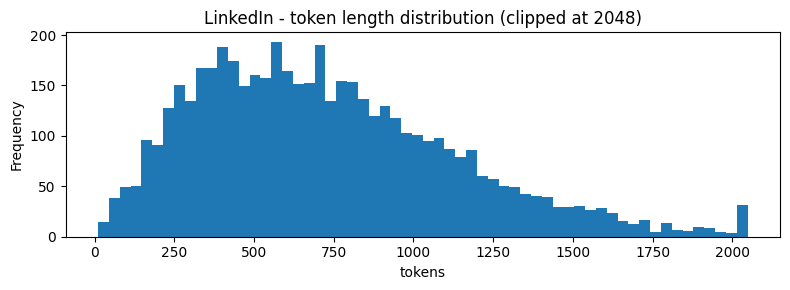

,Dataset,Sample size,Mean tokens,Median tokens,P90,P95,P99,Max,% > 512,% > 1024
0,Djinni,5000,406.0,370.0,672,796,1057,2875,24.9,1.2
1,LinkedIn,5000,730.3,674.0,1284,1495,1897,3038,65.5,21.9


In [20]:
# Measure token counts of the descriptions with the actual SmolLM2-360M tokenizer.
MODEL_NAME = "HuggingFaceTB/SmolLM2-360M"   # base model used for MP1
SAMPLE_FOR_TOKEN_ANALYSIS = 5000

try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print(f"Loaded tokenizer: {MODEL_NAME}\n")

    def count_tokens_batch(texts, batch_size=128):
        counts = []
        for i in range(0, len(texts), batch_size):
            batch = [str(t) for t in texts[i:i + batch_size]]
            enc = tokenizer(batch, add_special_tokens=True, truncation=False)
            counts.extend(len(ids) for ids in enc["input_ids"])
        return counts

    token_rows = []
    for dataset_name, col in target_cols.items():
        non_null = datasets[dataset_name][col].dropna().astype(str)
        sample   = non_null.sample(min(SAMPLE_FOR_TOKEN_ANALYSIS, len(non_null)), random_state=42)
        counts   = pd.Series(count_tokens_batch(sample.tolist()), name="tokens")

        token_rows.append({
            "Dataset":        dataset_name,
            "Sample size":    len(sample),
            "Mean tokens":    round(counts.mean(), 1),
            "Median tokens":  round(counts.median(), 1),
            "P90":            int(counts.quantile(0.90)),
            "P95":            int(counts.quantile(0.95)),
            "P99":            int(counts.quantile(0.99)),
            "Max":            int(counts.max()),
            "% > 512":        round((counts > 512).mean() * 100, 1),
            "% > 1024":       round((counts > 1024).mean() * 100, 1),
        })

        ax = counts.clip(upper=2048).plot.hist(
            bins=60, figsize=(8, 3),
            title=f"{dataset_name} - token length distribution (clipped at 2048)")
        ax.set_xlabel("tokens")
        plt.tight_layout()
        plt.show()

    display(pd.DataFrame(token_rows))

except Exception as e:
    print("Tokenizer analysis skipped - install transformers and verify model access.")
    print("Error:", repr(e))


With the SmolLM2-360M tokenizer, a Djinni description averages 406 tokens and a LinkedIn description 730. The two datasets differ most at the tail: 25 percent of Djinni descriptions exceed 512 tokens and only 1 percent exceed 1,024, whereas 66 percent of LinkedIn descriptions exceed 512 tokens and 22 percent exceed 1,024. A training block size of 1,024 tokens therefore holds almost every Djinni posting in full, which supports both the block size chosen in Section 4 and the use of Djinni as the training set.

### 2.7.1 Technical-term fragmentation

A general-purpose tokenizer may split a domain-specific term such as Kubernetes or CI/CD into several sub-word tokens. Heavy fragmentation has two costs: the model sees the concept spread across more positions, which makes it harder to learn, and the token budget is used up faster than the character count suggests. This subsection tokenises a set of common technical terms and counts the sub-tokens of each.


,term,n_tokens,sub-tokens
15,RabbitMQ,4,Rab | bit | M | Q
9,React.js,4,Re | act | . | js
0,Kubernetes,3,K | uber | netes
1,CI/CD,3,CI | / | CD
16,ElasticSearch,3,El | astic | Search
3,PostgreSQL,3,Post | gre | SQL
8,Terraform,3,Ter | ra | form
4,Dockerfile,3,D | ocker | file
12,LangChain,3,L | ang | Chain
13,OpenTelemetry,3,Open | Tele | metry


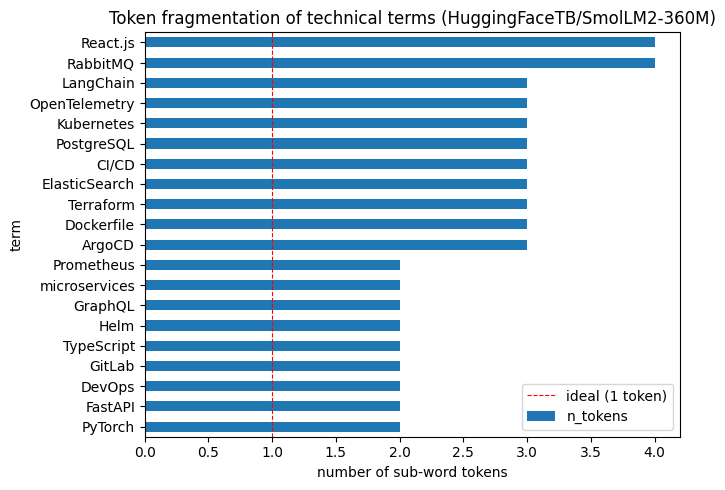

In [21]:
# Tokenise a set of technical terms and count the sub-tokens of each, to
# show how heavily a general-purpose tokenizer splits domain vocabulary.
TECHNICAL_TERMS = [
    "Kubernetes", "CI/CD", "TypeScript", "PostgreSQL", "Dockerfile",
    "microservices", "DevOps", "GitLab", "Terraform", "React.js",
    "FastAPI", "PyTorch", "LangChain", "OpenTelemetry", "GraphQL",
    "RabbitMQ", "ElasticSearch", "Helm", "ArgoCD", "Prometheus"
]

try:
    rows_frag = []
    for term in TECHNICAL_TERMS:
        ids     = tokenizer.encode(term, add_special_tokens=False)
        tokens  = tokenizer.convert_ids_to_tokens(ids)
        rows_frag.append({
            "term":        term,
            "n_tokens":    len(ids),
            "sub-tokens":  " | ".join(tokens),
        })

    frag_df = pd.DataFrame(rows_frag).sort_values("n_tokens", ascending=False)
    display(frag_df)

    ax = frag_df.sort_values("n_tokens").plot.barh(
        x="term", y="n_tokens", legend=False, figsize=(7, 5),
        title=f"Token fragmentation of technical terms ({MODEL_NAME})")
    ax.set_xlabel("number of sub-word tokens")
    ax.axvline(1, color="red", linestyle="--", linewidth=0.8, label="ideal (1 token)")
    ax.legend()
    plt.tight_layout()
    plt.show()

except NameError:
    print("Tokenizer not loaded - run the cell above first.")

None of the twenty technical terms tested is a single token. Most split into two or three sub-tokens, and a few into four. The tokenizer was trained on general text and has not learned these terms as units. Continued pretraining helps indirectly: training on a large amount of IT text gives the model far more exposure to these multi-token patterns, so it learns to handle them even though the tokenizer itself does not change.

## 2.8 Semantic embedding analysis

This section checks whether job descriptions group into coherent clusters by role. If postings for similar roles end up close together, that is further evidence the dataset carries learnable structure.

Each description is turned into a numeric vector, an embedding, using a sentence-transformer model. The embedding places descriptions with similar meaning close together, so the geometry of the resulting vectors shows whether the dataset separates into role-based groups.


In [22]:
# Build a numeric vector (embedding) for a sample of descriptions.
# Uses sentence-transformers if available, otherwise a TF-IDF fallback.
import numpy as np
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_extraction.text import TfidfVectorizer

SAMPLE_FOR_EMBEDDINGS = 1500
RANDOM_STATE = 42

sem_df = (
    djinni.dropna(subset=["Long Description", "Primary Keyword"])
    .sample(min(SAMPLE_FOR_EMBEDDINGS, len(djinni)), random_state=RANDOM_STATE)
    .reset_index(drop=True)
)
texts_sem  = sem_df["Long Description"].astype(str).tolist()
labels_sem = sem_df["Primary Keyword"].astype(str).tolist()

try:
    from sentence_transformers import SentenceTransformer
    emb_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    embeddings = emb_model.encode(texts_sem, show_progress_bar=True,
                                   normalize_embeddings=True)
    embedding_source = "sentence-transformers/all-MiniLM-L6-v2"
except Exception as e:
    print("sentence-transformers unavailable - falling back to TF-IDF + SVD.")
    print("Note: clusters in this mode reflect shared vocabulary, not semantics.")
    print("Error:", repr(e))
    vec  = TfidfVectorizer(max_features=5000, stop_words="english", min_df=3)
    X    = vec.fit_transform(texts_sem)
    svd  = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
    embeddings = svd.fit_transform(X)
    embedding_source = "TF-IDF + TruncatedSVD (vocabulary overlap, not semantics)"

print("Embedding source:", embedding_source)
print("Matrix shape    :", embeddings.shape)



sentence-transformers unavailable - falling back to TF-IDF + SVD.
Note: clusters in this mode reflect shared vocabulary, not semantics.
Error: ModuleNotFoundError("No module named 'sentence_transformers'")
Embedding source: TF-IDF + TruncatedSVD (vocabulary overlap, not semantics)
Matrix shape    : (1500, 100)


### 2.8.1 2D projection of semantic clusters

This visualisation is a diagnostic, not a model metric. It projects the embeddings down to two dimensions to show whether the dataset contains separable role and domain families.


UMAP unavailable - falling back to PCA.


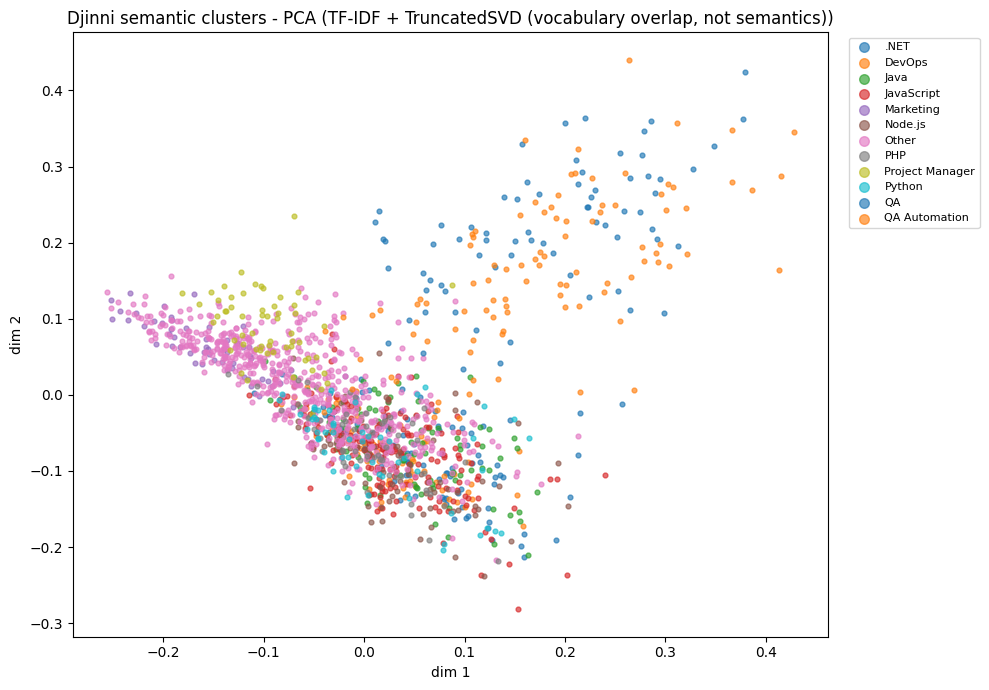

In [23]:
# Project the embeddings to 2D (UMAP if available, otherwise PCA) and
# scatter-plot them, coloured by primary keyword.
top_label_count = 12
top_labels  = pd.Series(labels_sem).value_counts().head(top_label_count).index
plot_labels = [x if x in top_labels else "Other" for x in labels_sem]

try:
    import umap
    reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, random_state=RANDOM_STATE)
    coords  = reducer.fit_transform(embeddings)
    method  = "UMAP"
except Exception as e:
    print("UMAP unavailable - falling back to PCA.")
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(embeddings)
    method = "PCA"

plot_df = pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "label": plot_labels})

fig, ax = plt.subplots(figsize=(10, 7))
for label, grp in plot_df.groupby("label"):
    ax.scatter(grp["x"], grp["y"], s=12, alpha=0.65, label=label)
ax.set_title(f"Djinni semantic clusters - {method} ({embedding_source})")
ax.set_xlabel("dim 1");  ax.set_ylabel("dim 2")
ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



The projection shows soft but real structure. Postings for related roles tend to fall in the same region rather than forming sharply separated islands. Marketing forms the most distinct group, which is expected, because it is the least IT-oriented of the categories and its vocabulary differs most from the rest. DevOps also holds together as a recognisable region. The web and back-end stacks, JavaScript, Node.js, PHP and Java, sit close to one another, which is correct, since these roles genuinely share skills and phrasing.

The groups are not crisply separated, for two reasons that are themselves informative. First, job postings share a large amount of common structure: a company description, a responsibilities list, a requirements list, an offer section. Much of every posting is this shared boilerplate, so the role-specific signal is only a part of the text, and the embeddings place all postings in one continuous space. Second, several of the keyword labels overlap by nature, so some of the blurring reflects categories that genuinely are similar rather than a weakness of the method. The catch-all "Other" label, being heterogeneous, is spread across the whole plot.

The dataset therefore carries genuine role structure, and it is clearest where the vocabulary is most distinctive.


### 2.8.2 Nearest-neighbour inspection

A cluster plot can be subjective. Nearest-neighbour examples are a more concrete check: for a chosen posting, do the closest descriptions refer to similar roles?


In [24]:
# For one posting per target domain, show its nearest neighbours by cosine
# similarity, to check that similar roles use similar language.
from sklearn.metrics.pairwise import cosine_similarity

# Normalise once
norms  = np.linalg.norm(embeddings, axis=1, keepdims=True)
E_norm = embeddings / np.maximum(norms, 1e-12)

def show_neighbours(query_idx, n=5):
    sims   = cosine_similarity(E_norm[query_idx:query_idx+1], E_norm).ravel()
    nbrs   = sims.argsort()[::-1][1:n+1]
    print(f"{'='*70}")
    print(f"QUERY  #{query_idx}  |  role/domain: {labels_sem[query_idx]}")
    print(texts_sem[query_idx][:500], "...\n")
    for rank, idx in enumerate(nbrs, 1):
        print(f"  #{rank} | sim={sims[idx]:.3f} | role/domain: {labels_sem[idx]}")
        print(" ", texts_sem[idx][:300], "...\n")

# Pick one representative index for each target domain.
# The search below selects the first occurrence of each keyword in the sample.
target_domains = ["DevOps", "Data Science", "Design"]
for domain in target_domains:
    hits = [i for i, l in enumerate(labels_sem) if domain.lower() in l.lower()]
    if hits:
        show_neighbours(hits[0])
    else:
        print(f"Domain '{domain}' not found in sample - try adjusting the list.")



QUERY  #27  |  role/domain: DevOps
About:
Our customer implements the optimal, secured cloud architecture with the optimal cost for the company's services and specializes in clients who are considering, planning, or actively moving to cloud computing.

Technologies: AWS Lambda, Google Cloud Platform, CI/CD, K8s, Jenkins, Python.

Responsibilities:
- Working on GCP / AWS Cloud environment;
- Performing DevOps for the client including CICD / Automation process;
- Security configuration;
- Building and implementing Cloud Pr ...

  #1 | sim=0.697 | role/domain: DevOps
  As a DevOps Engineer you will manage infrastructure tools such as build system, deployments, backups, and monitoring, as well as integration between services.

**Required experience and skills:**

B.S. in Computer Science, related fields or related work experience;
Strong knowledge in one of th ...

  #2 | sim=0.653 | role/domain: DevOps
  Responsibilities:

You will be part of a DevOps/ team who will play a significant rol

The nearest-neighbour results match the picture from the projection. For the DevOps query, the five closest descriptions are four other DevOps postings and one cloud-focused support role, with high similarity scores of about 0.76 to 0.80. This is a tight, coherent neighbourhood.

The data-science query is a web-analyst role at a digital marketing agency, and its neighbours are a mix of marketing, data and analyst postings. The keyword labels differ, but the content is consistent: all of these are analytics-oriented roles, and the query genuinely sits at the boundary between data and marketing. The similarity scores are lower, about 0.57 to 0.67, which reflects that this part of the space is more diffuse.

The design query is the least clean of the three: only two of its five neighbours are clearly design roles, the others being analyst, automation and developer postings, with moderate similarity scores bunched around 0.70 to 0.73. Design postings are harder to separate by language alone.

Taken together, the check confirms the conclusion of this phase: similar roles use similar language, and the separation is sharpest for well-defined technical domains such as DevOps and softer for broader or overlapping roles.


## 2.9 Summary of data understanding

The Data Understanding phase establishes that the data is suitable for the project and fixes the decisions carried into corpus construction.

Djinni is the stronger training set. It provides 141,897 IT job postings whose descriptions are all present and all unique, with no template repetition. Its text is moderately long (median 1,629 characters, about 370 tokens), and only 1 percent of postings exceed 1,024 tokens, so a 1,024-token training block holds almost every posting in full. The dataset also carries usable structure: a primary keyword, an experience level and an English level, with skills that map coherently onto roles.

LinkedIn is the right out-of-domain test set. It is genuinely cross-industry, with most titles falling outside the IT-oriented families, a wider vocabulary, and longer descriptions. It also contains about 13 percent duplicate descriptions, which must be removed before use.

These observations lead to four decisions for Section 3. Training, validation and in-domain testing use Djinni; out-of-domain testing uses LinkedIn. Descriptions are bounded by length to drop stubs and outliers. LinkedIn text is deduplicated. All splits are drawn with a fixed random seed, so the corpus is reproducible.


# 3. Data Preparation

This phase applies the decisions reached in Section 2. It turns the two raw datasets into a fixed corpus of plain text: the corpus the model is trained and evaluated on.

## 3.1 Corpus design and construction

Continued pretraining needs only raw text, with no labels and no instructions. The corpus is therefore stored as plain job descriptions, one JSON record of the form {"text": ...} per line, split across four files.

The build follows the recommendations from Section 2.5. Each description is kept only if its length is between 200 and 8,000 characters, which drops empty stubs and a small number of extreme outliers. LinkedIn descriptions are deduplicated first, because about 13 percent of them repeat. Djinni supplies three disjoint splits, drawn from one shuffled pool so they never overlap: a training set, a validation set used to monitor training, and an in-domain test set. LinkedIn supplies a single out-of-domain test set that is never used for training. A fixed random seed makes the whole process reproducible.

| Parameter | Value | Reason |
|---|---|---|
| Length bounds | 200 to 8,000 characters | drop empty stubs and outlier walls of text (Sections 2.2.3 and 2.3.2) |
| LinkedIn deduplication | applied | about 13 percent of LinkedIn descriptions repeat (Section 2.3.5) |
| Djinni splits | 12,000 train, 1,000 validation, 1,000 in-domain test | disjoint, all in-domain |
| LinkedIn split | 1,000 out-of-domain test | never used for training |
| Random seed | 42 | reproducible shuffling and splitting |


In [25]:
# Build the MP1 corpus: clean and split the datasets into train, val,
# in-domain test and out-of-domain test files, one JSON record per line.
import json
import random

MP1_CORPUS = PROJECT_ROOT / "data" / "processed" / "mp1"
MP1_CORPUS.mkdir(parents=True, exist_ok=True)

SEED = 42
MIN_CHARS, MAX_CHARS = 200, 8000             # drop stubs and outlier walls of text
N_TRAIN, N_VAL, N_TEST, N_OOD = 12_000, 1_000, 1_000, 1_000


def clean(series):
    """Drop nulls, strip whitespace, keep only descriptions within length bounds."""
    s = series.dropna().astype(str).str.strip()
    return s[s.str.len().between(MIN_CHARS, MAX_CHARS)]


def write_split(name, texts):
    """Write one {"text": ...} record per line; return a summary row."""
    path = MP1_CORPUS / f"{name}.jsonl"
    with open(path, "w", encoding="utf-8") as f:
        for t in texts:
            f.write(json.dumps({"text": t}, ensure_ascii=False) + "\n")
    chars = sum(len(t) for t in texts)
    return {"split": name, "docs": len(texts),
            "MB": round(path.stat().st_size / 1e6, 1),
            "~tokens (est.)": chars // 4}


rng = random.Random(SEED)

# Djinni: in-domain train / val / test (disjoint slices of one shuffled pool)
dj_texts = clean(djinni["Long Description"]).tolist()
assert len(dj_texts) >= N_TRAIN + N_VAL + N_TEST, "not enough clean Djinni docs"
rng.shuffle(dj_texts)
train = dj_texts[:N_TRAIN]
val   = dj_texts[N_TRAIN:N_TRAIN + N_VAL]
test  = dj_texts[N_TRAIN + N_VAL:N_TRAIN + N_VAL + N_TEST]

# LinkedIn: out-of-domain test (deduplicated; never used for training)
lk_texts = clean(linkedin["description"]).drop_duplicates().tolist()
rng.shuffle(lk_texts)
ood = lk_texts[:N_OOD]

summary = [write_split("train", train), write_split("val", val),
           write_split("test", test), write_split("ood_test", ood)]
print(f"MP1 corpus written to {MP1_CORPUS}/  (seed={SEED})")
pd.DataFrame(summary).set_index("split")

MP1 corpus written to /home/pedro/iscte/atlm_pro/data/processed/mp1/  (seed=42)


,docs,MB,~tokens (est.)
split,,,
train,12000,22.7,5387796
val,1000,1.9,452643
test,1000,1.9,447152
ood_test,1000,3.5,870547


## 3.2 Resulting corpus splits

The build produces four files in `data/processed/mp1/`. The training set holds 12,000 job descriptions, about 22.7 MB of text and roughly 5.4 million tokens. The validation and in-domain test sets hold 1,000 Djinni descriptions each. The out-of-domain test set holds 1,000 LinkedIn descriptions; it is larger in bytes than a Djinni split of the same document count, because LinkedIn descriptions are about twice as long.

This is the corpus used for the rest of the project. Section 4 trains on the training set and monitors progress on the validation set. Section 5 measures perplexity on the two held-out test sets: `test` for in-domain performance and `ood_test` for out-of-domain generalisation.


# 4. Modeling

This phase runs the continued-pretraining experiment. Two training runs are carried out on the corpus built in Section 3. They differ only in the optimisation method, full fine-tuning in one and LoRA in the other, so the two methods can be compared fairly.

## 4.1 Continued-pretraining setup

Both runs continue the pretraining of the base SmolLM2-360M model on the training split of the corpus. The objective is plain next-token prediction, with no labels and no instructions, exactly as described in Section 1.6.

The base model is SmolLM2-360M. The SmolLM2 family was chosen for three reasons: it is openly available, it is a current small-model family designed for limited-hardware work, and its models share one tokenizer across sizes, which made the comparison between 135M and 360M in Section 5.5 friction-free. Within the family, the 360M model is used as the main model: it is small enough that full fine-tuning fits on a single consumer GPU, and, as Section 5.5 shows, it gives clearly lower perplexity than the 135M model, at a higher training cost. The 1.7B model in the family was not used, because full fine-tuning at that size would not fit the available hardware. The 360M model is therefore the point where capacity and compute are balanced for this project.

Everything except the optimisation method is held constant across the two runs: the same data, the same number of epochs, the same effective batch size, and the same learning-rate schedule shape. This is what makes the comparison a controlled experiment. The one exception is the learning rate itself, which is set to the value conventional for each method; this point is discussed in Sections 5.2 and 5.7.

All training and evaluation were run on a single NVIDIA RTX 4090 GPU with 24 GB of memory, under WSL2. Each run trains for three epochs on the 12,000-document training set; the per-run wall-clock times are reported in the Section 5.4 summary, and the two runs together take on the order of one hour. That is the compute budget of the experiment.

For reproducibility, a single random seed (42) is fixed for the corpus construction, the training, and the sampling used in the analyses, and the exact version of every library is pinned in requirements.lock.txt. One caveat: training on a GPU is not bit-for-bit deterministic, because some CUDA operations are not, so the perplexity figures can vary slightly between runs even with the seed fixed. That variation is small, well below the differences this report draws conclusions from.

The cells below define the configuration, a function that tokenises the corpus into fixed-length blocks, and a function that runs one training job. The two runs are then launched in turn.


In [4]:
# Training configuration. The values marked "held constant" are identical
# for both runs; only the learning rate and LoRA settings differ by mode.
import itertools, json, math, time

import torch
from datasets import load_dataset
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          DataCollatorForLanguageModeling, Trainer,
                          TrainingArguments, set_seed)
from peft import LoraConfig, get_peft_model

MODEL = "HuggingFaceTB/SmolLM2-360M"            # base model (NOT -Instruct)
RUN = "mp1-360m"                                # this run's output-folder tag
CORPUS = PROJECT_ROOT / "data" / "processed" / "mp1"
OUTPUTS = PROJECT_ROOT / "outputs"
RUN_DIR = OUTPUTS / RUN                         # outputs/mp1-360m/  (full/ lora/ eval.json)
BLOCK_SIZE = 1024
SEED = 42

# --- held constant across both modes ---
EPOCHS = 3
PER_DEVICE_BATCH = 4
GRAD_ACCUM = 4                                  # effective batch = 16
WARMUP_RATIO = 0.03
WEIGHT_DECAY = 0.01

# --- the experiment knob: full fine-tuning vs LoRA ---
MODE_CFG = {
    "full": {"learning_rate": 5e-5},
    "lora": {"learning_rate": 2e-4, "r": 16, "alpha": 32, "dropout": 0.05,
             "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj",
                                "gate_proj", "up_proj", "down_proj"]},
}
print("config ready - base model:", MODEL)

config ready - base model: HuggingFaceTB/SmolLM2-360M


In [5]:
# Helper: tokenise a corpus file and pack the tokens into fixed-size blocks.
def tokenize_and_chunk(jsonl_path, tokenizer, block_size=BLOCK_SIZE):
    """Tokenize raw text, mark doc boundaries with EOS, pack into fixed blocks."""
    ds = load_dataset("json", data_files=str(jsonl_path), split="train")

    def tok(batch):
        out = tokenizer(batch["text"])
        for ids in out["input_ids"]:
            ids.append(tokenizer.eos_token_id)
        return {"input_ids": out["input_ids"]}

    ds = ds.map(tok, batched=True, remove_columns=ds.column_names)

    def group(batch):
        ids = list(itertools.chain.from_iterable(batch["input_ids"]))
        n = (len(ids) // block_size) * block_size
        blocks = [ids[i:i + block_size] for i in range(0, n, block_size)]
        return {"input_ids": blocks,
                "attention_mask": [[1] * block_size for _ in blocks]}

    return ds.map(group, batched=True)

In [6]:
# Run one continued-pretraining job in the given mode, and save its outputs.
def run_training(mode):
    """Continued pretraining in `mode` ('full' or 'lora'); returns a summary dict."""
    cfg = MODE_CFG[mode]
    set_seed(SEED)
    out_dir = RUN_DIR / mode

    tokenizer = AutoTokenizer.from_pretrained(MODEL)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(MODEL)

    # LoRA mode: wrap the model so only the small adapter parameters train.
    if mode == "lora":
        model = get_peft_model(model, LoraConfig(
            r=cfg["r"], lora_alpha=cfg["alpha"], lora_dropout=cfg["dropout"],
            target_modules=cfg["target_modules"], task_type="CAUSAL_LM"))
        model.print_trainable_parameters()
    else:
        print("full fine-tuning - all parameters trainable")

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())

    train_ds = tokenize_and_chunk(CORPUS / "train.jsonl", tokenizer)
    val_ds = tokenize_and_chunk(CORPUS / "val.jsonl", tokenizer)
    print(f"train blocks: {len(train_ds):,} | val blocks: {len(val_ds):,}")

    # Trainer settings: shared values plus this mode's learning rate.
    args = TrainingArguments(
        output_dir=str(out_dir),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=PER_DEVICE_BATCH,
        per_device_eval_batch_size=PER_DEVICE_BATCH,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=cfg["learning_rate"],
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        bf16=True,
        eval_strategy="steps", eval_steps=50, logging_steps=10,
        save_strategy="no", seed=SEED, report_to=[],
    )
    trainer = Trainer(
        model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
        processing_class=tokenizer,
    )

    # Train the model, timing the run.
    t0 = time.time()
    trainer.train()
    minutes = (time.time() - t0) / 60

    out_dir.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(out_dir))
    tokenizer.save_pretrained(str(out_dir))

    # Final validation metrics; also save the log history and a summary file.
    final = trainer.evaluate()
    summary = {"mode": mode, "learning_rate": cfg["learning_rate"],
               "trainable_params": trainable_params, "total_params": total_params,
               "minutes": round(minutes, 1),
               "final_val_loss": round(final["eval_loss"], 4),
               "val_perplexity": round(math.exp(final["eval_loss"]), 2)}
    (out_dir / "log_history.json").write_text(
        json.dumps(trainer.state.log_history, indent=1))
    (out_dir / "summary.json").write_text(json.dumps(summary, indent=1))
    print("done:", summary)
    return summary

## 4.2 Run A: full fine-tuning

The first run is full fine-tuning: every weight in the model is updated during training. The cell reports the number of trainable parameters and the wall-clock time, and writes them to the run summary that Section 5.4 reads.


In [29]:
# Run A: full fine-tuning. This trains the model and can take a while.
summary_full = run_training("full")

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1937.50it/s]


full fine-tuning - all parameters trainable


Generating train split: 12000 examples [00:00, 147190.08 examples/s]
Map: 100%|██████████| 12000/12000 [00:01<00:00, 8990.94 examples/s]
Generating train split: 1000 examples [00:00, 208329.81 examples/s]
Map: 100%|██████████| 1000/1000 [00:00<00:00, 7590.22 examples/s]
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


train blocks: 4,711 | val blocks: 396


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 0}.


Step,Training Loss,Validation Loss
50,2.677489,2.696642
100,2.673740,2.650667
150,2.633839,2.628008
200,2.595102,2.612798
250,2.585917,2.602350
300,2.551373,2.594478
350,2.575838,2.588579
400,2.547861,2.584398
450,2.566652,2.580922
500,2.575890,2.578392


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.22s/it]


Training Loss,Validation Loss,Step
2.537273,2.573471,885


done: {'mode': 'full', 'learning_rate': 5e-05, 'trainable_params': 361821120, 'total_params': 361821120, 'minutes': 33.9, 'final_val_loss': 2.5735, 'val_perplexity': 13.11}


## 4.3 Run B: LoRA

The second run uses LoRA. The base weights are frozen and only the small low-rank adapter matrices are trained, so the number of trainable parameters is a small fraction of the full model.

Both runs use the same micro-batch size of 4 with gradient accumulation over 4 steps, for an effective batch size of 16. The reason the micro-batch is kept this small, rather than larger, is a memory limit described in Section 5.7.


In [7]:
# Run B: LoRA. Same data and schedule as Run A; only the method differs.
summary_lora = run_training("lora")

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1906.64it/s]


trainable params: 8,683,520 || all params: 370,504,640 || trainable%: 2.3437


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


train blocks: 4,711 | val blocks: 396


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 0}.


Step,Training Loss,Validation Loss
50,2.616941,2.632327
100,2.576091,2.551980
150,2.522019,2.516574
200,2.478403,2.493567
250,2.470753,2.478015
300,2.418691,2.466581
350,2.436654,2.457355
400,2.403265,2.449588
450,2.413525,2.441113
500,2.430613,2.434327


Training Loss,Validation Loss,Step
2.365285,2.411286,885


done: {'mode': 'lora', 'learning_rate': 0.0002, 'trainable_params': 8683520, 'total_params': 370504640, 'minutes': 48.6, 'final_val_loss': 2.4113, 'val_perplexity': 11.15}


# 5. Evaluation

This phase evaluates the result of the training. It compares three models: the untrained base model, the model after full fine-tuning, and the model after LoRA. The evaluation has four parts: the training loss curves, test-set perplexity, a qualitative look at generated text, and a consolidated summary. It closes with a comparison against a smaller model and a discussion of what the results mean.

Evaluation uses the two held-out test sets built in Section 3. The in-domain test set contains Djinni IT postings the model never saw during training. The out-of-domain test set contains LinkedIn postings from many industries. Comparing performance on the two sets shows whether adapting the model to IT job postings also helps on postings from other fields.


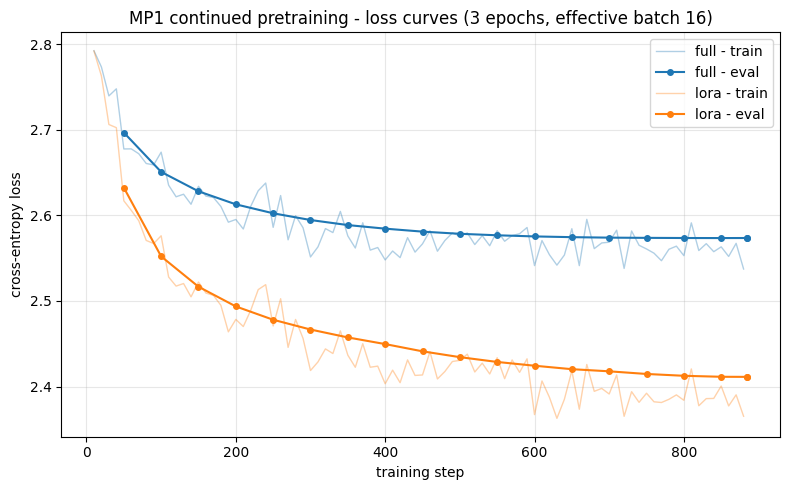

In [8]:
# Plot the training and validation loss curves for both training runs.
import json



def load_curves(mode):
    """Return (train_steps, train_loss), (eval_steps, eval_loss) for a run."""
    hist = json.loads((RUN_DIR / mode / "log_history.json").read_text())
    train = [(e["step"], e["loss"]) for e in hist if "loss" in e]
    evals = [(e["step"], e["eval_loss"]) for e in hist if "eval_loss" in e]
    return train, evals


fig, ax = plt.subplots(figsize=(8, 5))
for mode, color in [("full", "tab:blue"), ("lora", "tab:orange")]:
    train, evals = load_curves(mode)
    ts, tl = zip(*train)
    es, el = zip(*evals)
    ax.plot(ts, tl, color=color, alpha=0.35, linewidth=1, label=f"{mode} - train")
    ax.plot(es, el, color=color, marker="o", markersize=4, label=f"{mode} - eval")

ax.set_xlabel("training step")
ax.set_ylabel("cross-entropy loss")
ax.set_title("MP1 continued pretraining - loss curves (3 epochs, effective batch 16)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5.1 Training dynamics

The first check is the training loss. The plot below shows the training and validation loss for both runs across the three epochs. Healthy training shows both curves falling and then levelling off, with the validation curve tracking the training curve rather than rising away from it, which would indicate overfitting.


## 5.2 Perplexity evaluation

This section measures test-set perplexity, the main quantitative metric of the experiment. The cell below scores all three models, the base model and the two trained variants, on both held-out test sets, and also produces a short sample generation from each. Lower perplexity means the model found the text more predictable, so a model well adapted to job postings should score lower on the in-domain test set than the base model does.


In [9]:
# Evaluate all three models (base, full, lora) on both held-out test sets:
# compute perplexity and greedy sample generations, then write eval.json.
import json
import math

import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

EVAL_BLOCK = 1024
DEVICE = "cuda"
DTYPE = torch.bfloat16
EVAL_SETS = {"in_domain": CORPUS / "test.jsonl", "ood": CORPUS / "ood_test.jsonl"}
EVAL_PROMPTS = ["We are looking for a", "The ideal candidate will", "Responsibilities:\n-"]


def eval_base_id():
    """Base model id, read from this run's LoRA adapter config; never hardcoded."""
    cfg = json.loads((RUN_DIR / "lora" / "adapter_config.json").read_text())
    return cfg["base_model_name_or_path"]


def make_eval_blocks(jsonl_path, tokenizer):
    """Tokenize a jsonl corpus and pack into fixed-size blocks for perplexity."""
    ds = load_dataset("json", data_files=str(jsonl_path), split="train")
    ids = []
    for text in ds["text"]:
        ids.extend(tokenizer(text)["input_ids"])
        ids.append(tokenizer.eos_token_id)
    n = (len(ids) // EVAL_BLOCK) * EVAL_BLOCK
    return [ids[i:i + EVAL_BLOCK] for i in range(0, n, EVAL_BLOCK)]


@torch.no_grad()
def block_perplexity(model, blocks):
    """Token-weighted perplexity over a list of equal-length blocks."""
    tot_loss, tot_tok = 0.0, 0
    for i in range(0, len(blocks), 8):
        batch = torch.tensor(blocks[i:i + 8], device=DEVICE)
        loss = model(batch, labels=batch).loss
        n = batch.shape[0] * (batch.shape[1] - 1)
        tot_loss += loss.item() * n
        tot_tok += n
    return math.exp(tot_loss / tot_tok)


def load_eval_model(name):
    """Load 'base' | 'full' | 'lora' for this run onto the GPU in eval mode."""
    if name == "lora":
        from peft import PeftModel
        m = AutoModelForCausalLM.from_pretrained(eval_base_id())
        m = PeftModel.from_pretrained(m, str(RUN_DIR / "lora"))
    elif name == "full":
        m = AutoModelForCausalLM.from_pretrained(str(RUN_DIR / "full"))
    else:  # base
        m = AutoModelForCausalLM.from_pretrained(eval_base_id())
    return m.to(DEVICE, dtype=DTYPE).eval()


eval_tok = AutoTokenizer.from_pretrained(eval_base_id())
if eval_tok.pad_token is None:
    eval_tok.pad_token = eval_tok.eos_token
eval_blocks = {name: make_eval_blocks(path, eval_tok)
               for name, path in EVAL_SETS.items()}

eval_results = {"perplexity": {}, "generations": {}}
for name in ("base", "full", "lora"):
    print(f"evaluating {name} ...", flush=True)
    model = load_eval_model(name)
    eval_results["perplexity"][name] = {
        s: round(block_perplexity(model, b), 2) for s, b in eval_blocks.items()}
    gens = []
    for prompt in EVAL_PROMPTS:
        enc = eval_tok(prompt, return_tensors="pt").to(DEVICE)
        out = model.generate(**enc, max_new_tokens=80, do_sample=False,
                             pad_token_id=eval_tok.eos_token_id)
        gens.append({"prompt": prompt,
                     "output": eval_tok.decode(out[0], skip_special_tokens=True)})
    eval_results["generations"][name] = gens
    del model
    torch.cuda.empty_cache()

(RUN_DIR / "eval.json").write_text(
    json.dumps(eval_results, indent=2, ensure_ascii=False))
print(f"evaluation written -> {RUN_DIR / 'eval.json'}")

Generating train split: 1000 examples [00:00, 139137.63 examples/s]
Generating train split: 1000 examples [00:00, 82407.69 examples/s]


evaluating base ...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 970.22it/s]


evaluating full ...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 875.29it/s]


evaluating lora ...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1828.04it/s]


evaluation written -> /home/pedro/iscte/atlm_pro/outputs/mp1-360m/eval.json


In [10]:
# Build the test-set perplexity table from eval.json, showing each
# model's change relative to the base model.
evald = json.loads((RUN_DIR / "eval.json").read_text())
ppl = evald["perplexity"]
base = ppl["base"]

rows = []
for model in ["base", "full", "lora"]:
    p = ppl[model]
    rows.append({
        "model": {"base": "base SmolLM2-360M",
                  "full": "full fine-tuning",
                  "lora": "LoRA r=16"}[model],
        "in-domain ppl": p["in_domain"],
        "OOD ppl": p["ood"],
        "in-domain vs base": f'{(p["in_domain"] / base["in_domain"] - 1) * 100:+.0f}%',
        "OOD vs base": f'{(p["ood"] / base["ood"] - 1) * 100:+.0f}%',
    })

ppl_table = pd.DataFrame(rows).set_index("model")
print("Test-set perplexity (lower = better)\n")
ppl_table

Test-set perplexity (lower = better)



,in-domain ppl,OOD ppl,in-domain vs base,OOD vs base
model,,,,
base SmolLM2-360M,16.37,17.80,+0%,+0%
full fine-tuning,13.12,17.42,-20%,-2%
LoRA r=16,11.37,18.24,-31%,+2%


The table reports each model's perplexity on both test sets, with the change relative to the base model. Two things are worth reading from it.

The first is in-domain adaptation: how far in-domain perplexity falls. A large fall means the model has absorbed the style and vocabulary of job postings.

The second is generalisation: how much out-of-domain perplexity moves. If out-of-domain perplexity barely changes while in-domain perplexity falls sharply, the adaptation is specific to IT and does not transfer to postings from other industries. That contrast is the main question the experiment was designed to answer.

One point must be stated plainly when comparing full fine-tuning with LoRA. The two runs are controlled on data, epochs, effective batch size and schedule shape, but not on the learning rate: LoRA uses 2e-4 and full fine-tuning uses 5e-5, each the conventional value for its method. Any difference between the two methods therefore includes the effect of this learning-rate difference, and is not attributed to the method alone.


## 5.3 Qualitative generation analysis

Perplexity is a single number. It helps to also read what the models actually produce. The cell below generates text from the same prompts with each of the three models, using greedy decoding. Greedy decoding always picks the most likely next token, which keeps the comparison consistent with the perplexity measurement, though it reads less naturally than sampled text.


In [11]:
# Print the greedy sample generations of all three models, grouped by prompt.
gens = evald["generations"]
prompts = [g["prompt"] for g in gens["base"]]

for i, prompt in enumerate(prompts):
    print("=" * 80)
    print(f"PROMPT: {prompt!r}")
    print("=" * 80)
    for model in ["base", "full", "lora"]:
        print(f"\n--- {model} ---")
        print(gens[model][i]["output"])
    print()

PROMPT: 'We are looking for a'

--- base ---
We are looking for a way to make the most of the data we have.

We are looking for a way to make the most of the data we have.

We are looking for a way to make the most of the data we have.

We are looking for a way to make the most of the data we have.

We are looking for a way to make the most of the data

--- full ---
We are looking for a Senior Software Engineer to join our team. We are looking for a Senior Software Engineer to join our team. We are looking for a Senior Software Engineer to join our team. We are looking for a Senior Software Engineer to join our team. We are looking for a Senior Software Engineer to join our team. We are looking for a Senior Software Engineer to join our team. We are looking for a Senior Software

--- lora ---
We are looking for a Senior Full Stack Developer to join our team.

**Responsibilities:**
- Develop and maintain the front-end of our product
- Collaborate with the product team to design and impl

The contrast is clear. The base model tends to fall into loops and produces little usable structure. After continued pretraining, both trained models produce recognisable job-posting prose: responsibility lists, offer sections and experience requirements. Some repetition remains, which is expected for a model of this size. Improving this output quality is the goal of Mini-Assignment 2, through supervised fine-tuning and alignment.


## 5.4 Results summary

The cell below consolidates the experiment into a single table. For each training method it reports the number of trainable parameters, the learning rate, the training time, and the in-domain and out-of-domain test perplexity with the change relative to the base model. It also reports which checkpoint achieved the best in-domain perplexity; that checkpoint is the one carried forward into Mini-Assignment 2.


In [12]:
# Consolidated results table, built from this run's saved artefacts.
ppl = json.loads((RUN_DIR / "eval.json").read_text())["perplexity"]
base_ppl = ppl["base"]


def vs_base(value, ref):
    return f"{value} ({(value / ref - 1) * 100:+.0f}%)"


summary_rows = {}
for mode, label in [("full", "full fine-tuning"), ("lora", "LoRA r=16")]:
    s = json.loads((RUN_DIR / mode / "summary.json").read_text())
    trn, tot = s["trainable_params"], s["total_params"]
    summary_rows[label] = {
        "trainable params": f"{trn / 1e6:.1f}M ({trn / tot * 100:.1f}%)",
        "learning rate": s["learning_rate"],
        "wall-clock (min)": s["minutes"],
        "in-domain test ppl": vs_base(ppl[mode]["in_domain"], base_ppl["in_domain"]),
        "OOD test ppl": vs_base(ppl[mode]["ood"], base_ppl["ood"]),
    }

best = min(["full", "lora"], key=lambda m: ppl[m]["in_domain"])
print(f"base model:  in-domain ppl {base_ppl['in_domain']}, OOD ppl {base_ppl['ood']}")
print(f"best in-domain fit: {best}  ->  checkpoint carried into MP2")
pd.DataFrame(summary_rows)

base model:  in-domain ppl 16.37, OOD ppl 17.8
best in-domain fit: lora  ->  checkpoint carried into MP2


,full fine-tuning,LoRA r=16
trainable params,361.8M (100.0%),8.7M (2.3%)
learning rate,0.00005,0.0002
wall-clock (min),33.9,48.6
in-domain test ppl,13.12 (-20%),11.37 (-31%)
OOD test ppl,17.42 (-2%),18.24 (+2%)


## 5.5 Model-size comparison: 135M vs 360M

Mini-Assignment 1 was carried out at two model sizes. This notebook uses SmolLM2-360M; an earlier notebook ran the same experiment with the smaller SmolLM2-135M. Each run writes its results to a separate folder, so the two do not overwrite each other.

The cell below reads the saved results of both runs and places their test perplexity side by side. The 135M column appears only if that run has also been carried out; otherwise the table shows the 360M results alone.


In [13]:
# 135M vs 360M: reads each run's eval.json (whichever exist on disk).
COMPARE = {"135M (v2)": "mp1-135m", "360M (v3)": "mp1-360m"}

ppl_by_run = {}
for label, run in COMPARE.items():
    path = OUTPUTS / run / "eval.json"
    if path.exists():
        ppl_by_run[label] = json.loads(path.read_text())["perplexity"]
    else:
        print(f"{label}: outputs/{run}/eval.json not found - run that notebook first.")

if ppl_by_run:
    rows = []
    for variant in ("base", "full", "lora"):
        row = {"variant": variant}
        for label, ppl in ppl_by_run.items():
            row[f"{label} · in-domain"] = ppl[variant]["in_domain"]
            row[f"{label} · OOD"] = ppl[variant]["ood"]
        rows.append(row)
    cmp_table = pd.DataFrame(rows).set_index("variant")
    print("MP1 model-size comparison - test perplexity (lower = better)\n")
    display(cmp_table)
else:
    print("No runs available to compare yet.")

135M (v2): outputs/mp1-135m/eval.json not found - run that notebook first.
MP1 model-size comparison - test perplexity (lower = better)



,360M (v3) · in-domain,360M (v3) · OOD
variant,,
base,16.37,17.80
full,13.12,17.42
lora,11.37,18.24


## 5.6 Discussion and conclusions

The experiment answers the question it was designed around. Continued pretraining adapts the model to the job-postings domain: in-domain perplexity falls clearly for both training methods, from the base model's level to a markedly lower value after training. Out-of-domain perplexity, measured on cross-industry LinkedIn postings, moves very little. The adaptation is therefore real but domain-specific: training on IT job postings makes the model better at IT job postings, and does not carry over to other industries.

Both optimisation methods achieve the in-domain adaptation, and LoRA does so while training only a small fraction of the parameters. As noted in Section 5.2, the comparison between the two methods is controlled on everything except the learning rate, so the gap between them reflects the combined effect of method and learning rate, not of the method alone.

The model-size comparison in Section 5.5 adds a second finding: the larger 360M model has lower perplexity than the smaller 135M model on every variant, and the gain is largest on the out-of-domain test set. Increasing model size and adapting to the domain are complementary, because they improve different things.

The checkpoint with the best in-domain perplexity is the one carried forward into Mini-Assignment 2, where supervised fine-tuning and alignment turn this domain-adapted text model into one that can follow recruiter instructions.


## 5.7 Difficulties encountered

This section reports the problems met during the work, the results that were unexpected, and what would be done differently. Honest reporting of these is more useful than presenting the project as if everything worked on the first attempt.

LoRA did not fit in GPU memory at the micro-batch size first intended. At a micro-batch of 16 it raised a CUDA out-of-memory error on this version of the transformers and peft libraries. The resolution was to lower the micro-batch to 4 and raise gradient accumulation to 4, which keeps the effective batch size at 16. Both runs use this setting, so the change does not affect the fairness of the comparison.

A library update broke working code. Version 5.9 of transformers removed the `overwrite_output_dir` argument from its training-arguments API, which the first version of the training script used, so the script failed until that argument was removed. This is a reminder that fast-moving libraries can break code between minor versions, which is why the exact versions are pinned in `requirements.lock.txt`.

The comparison between full fine-tuning and LoRA is not perfectly controlled. The two runs are held equal on data, epochs, effective batch size and schedule shape, but not on the learning rate: LoRA uses 2e-4 and full fine-tuning uses 5e-5, each the value conventional for its method. Holding the learning rate equal would put one of the methods outside its normal operating range. The position taken throughout Section 5 is to read the gap between the two methods as the combined effect of method and learning rate, not of the method alone.

The model size had to be reconsidered partway through. The experiment was first carried out with the smaller SmolLM2-135M. Its perplexity dropped as expected, but its sample generations were weak and repetitive, which made the qualitative results hard to judge. The experiment was repeated with SmolLM2-360M, and the 135M run was kept as the comparison baseline in Section 5.5. What we would do differently: decide the model size deliberately at the start, against a clear quality bar for the generated text, rather than discovering the need to scale up only after a full run.

Output files collided between the two runs. Running two model sizes through the same code initially overwrote each other's saved models and results, because the output paths did not include the run identity. The fix was a per-run output-folder scheme, in which each run writes to its own folder. What we would do differently: design the output layout for multiple runs from the start.

The result that most surprised us was how little the adaptation transferred out of domain. Continued pretraining lowered in-domain perplexity substantially, but out-of-domain perplexity on the cross-industry LinkedIn postings barely moved. We had expected at least a modest transfer, since all job postings share a common structure. In practice the adaptation was almost entirely specific to IT, which is discussed as a genuine finding in Section 5.6.


# 6. Deployment

This phase makes the trained model usable. It loads the three checkpoints and generates job-posting text from prompts supplied by the user, which shows the model's behaviour directly rather than through aggregate metrics.

## 6.1 Interactive generation

The numbers in Section 5 are aggregate. This section loads the checkpoints and generates text from a given prompt, so the output of the base model and the two trained models can be compared directly.

It is important to remember what a Mini-Assignment 1 model is. Continued pretraining produces a text completer, not a chat model. The model continues the start of a job posting; it does not answer instruction-style requests, such as a request to write a job description for a Java developer. Following instructions is the capability added in Mini-Assignment 2.

The generation logic is packaged in `src/generate_mp1.py`, which can also be used as a standalone command-line tool. The examples below decode with sampling (temperature 0.8, top-p 0.95, repetition penalty 1.3), which reads more naturally than the greedy decoding used for the perplexity measurement in Section 5.


In [14]:
import sys

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from generate_mp1 import load_model, generate

# Load all three checkpoints: the untrained base plus both adaptation methods,
# so generations can be compared the same three ways as the Section 5 table.
base_model, tokenizer = load_model("base", RUN)
full_model, _ = load_model("full", RUN)
lora_model, _ = load_model("lora", RUN)

MODELS = {"base": base_model, "full": full_model, "lora": lora_model}
print("loaded: base + full fine-tuned + LoRA-adapted SmolLM2-360M")

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1838.64it/s]


loaded: base + full fine-tuned + LoRA-adapted SmolLM2-360M


The cell below runs the same prompts through all three models. Each prompt is the opening of a job posting, which is the kind of text the model was trained to continue. The base model output is the starting point; the full fine-tuning and LoRA outputs show what the two training methods produced.


In [15]:
# Generate from a fixed set of job-posting openings with all three models.
prompts = [
    "Senior Backend Engineer\n\nWe are looking for",
    "Responsibilities:\n-",
    "Required skills:",
]

for p in prompts:
    print("=" * 80)
    print(f"PROMPT: {p!r}")
    print("=" * 80)
    for name, model in MODELS.items():
        print(f"\n--- {name} ---")
        print(generate(model, tokenizer, p, max_new_tokens=100))
    print()

PROMPT: 'Senior Backend Engineer\n\nWe are looking for'

--- base ---
Senior Backend Engineer

We are looking for an experienced Senior Front-End Developer to join our team. We have a diverse skill set with coding, design and UX experience in web development like: Javascript/HTML5 / CSS3 etc (all languages available).


  • Experience of developing front end application using HTML, CSS & JavaScript

  • Knowledge about how AJAX works? What is RESTful API ? How does it work together?.



  1. 20 hours + training on AWS
  2. Lead

--- full ---
Senior Backend Engineer

We are looking for a Senior Developer to join our team. We need someone who can drive the back-office system with high level of automation and use it as an opportunity platform within various projects, while providing support in different scenarios across DevOps teams (including production). Experience is welcome! If you have experience working on CI/CD tools such Jenkins or other continuous integration platforms will be ve

The cell below generates from a single editable prompt. Changing the prompt text, or the temperature and length settings, and running the cell again shows how each of the three models responds.


In [16]:
# Generate from a single editable prompt with all three models.
my_prompt = "Data Scientist experienced with"

for name, model in MODELS.items():
    print(f"--- {name} ---")
    print(generate(model, tokenizer, my_prompt, max_new_tokens=120, temperature=0.8))
    print()

--- base ---
Data Scientist experienced with statistical and graphical techniques, including correlation analysis.
487 views

--- full ---
Data Scientist experienced with statistical and machine learning algorithms
Experience in data analysis, writing reports, etc.
6+ years of experience as a Data Analyst or similar role within the organization

10-12 months to 3 + year’s professional relationship building from an external candidate source (internal recruiting is not possible at this time). Experience helping people become better customers are also very important for us! And that's how we build our business - by giving talent access into other teams who need it badly :) In case you have any queries regarding skills required: please do get back to me immediately :-) If

--- lora ---
Data Scientist experienced with statistical and graphical techniques, including correlation measures.
Experience in data preparation using various tools (R studio for example).

**Required skills:**
  • 1+ y

## 6.2 Limitations and path to Mini-Assignment 2

The Mini-Assignment 1 model has the limitations expected of its stage and size. It is a text completer: it continues a job posting but cannot follow an instruction or respect explicit constraints such as a required seniority or a specific list of skills. Its output still contains some repetition, especially under greedy decoding. The domain adaptation is specific to IT and does not transfer to other industries, as the out-of-domain results show. The model also has no access to real market data, such as current salary ranges.

These limitations define the next two stages. Mini-Assignment 2 adds supervised fine-tuning and preference alignment, so the model can follow recruiter instructions and respect stated constraints. The Final Project adds retrieval over real postings and an automatic quality-checking loop, which grounds the output in real market data and raises its reliability. The domain-adapted checkpoint produced here is the starting point for that work.
